In [1]:
import h5py
import o2sclpy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

class hdf5_reader:
    """
    Class to read an O2scl object from an HDF5 file. This is
    used by :py:class:`o2sclpy.plotter` to read HDF5 files.
    """

    list_of_dsets=[]
    """
    Data set list used by :py:func:`cloud_file.hdf5_is_object_type`.
    """
    search_type=''
    """
    O2scl type used by :py:func:`cloud_file.hdf5_is_object_type`.
    """

    def h5read_first_type(self,fname,loc_type):
        """
        Read the first object of type ``loc_type`` from file named ``fname``
        """
        del self.list_of_dsets[:]
        self.search_type=loc_type
        file=h5py.File(fname,'r')
        file.visititems(self.hdf5_is_object_type)
        if len(self.list_of_dsets)==0:
            str='Could not object of type '+loc_type+' in file '+fname+'.'
            raise RuntimeError(str)
        return file[self.list_of_dsets[0]]

    def h5read_name(self,fname,name):
        """
        Read object named ``name`` from file named ``fname``
        """
        file=h5py.File(fname,'r')
        obj=file[name]
        o2scl_type_dset=obj['o2scl_type']
        loc_type=o2scl_type_dset.__getitem__(0)
        return (obj,loc_type)
        
def mass_eta_interp(data,mass,eta,nz,name):
    """
    Interpolate data at mass 'mass' and eta 'eta' to 
    and return the array
    """

    # Compute 'eta_interval', the fraction of the interval
    # from one grid point to the next representing the
    # specified value of eta
    if eta<-12.0:
        eta_interval=(eta+17.0)/5.0
    else:
        eta_interval=(eta+12.0)/5.0

    # The value 'mass_index' is the index of the lower edge of the
    # interval on the mass grid containing the specified mass. We
    # ensure that the mass index is from 0 to 4 so that we can use the
    # interval from 'mass_index' to 'mass_index+1'.
    mass_index=int((mass-1.0)/0.2)
    if mass_index>=5:
        mass_index=4

    # Compute 'mass_interval', the fraction of the interval
    # from one grid point to the next representing the
    # specified value of the mass
    mass_interval=(mass-(mass_index*0.2+1.0))/0.2

    if False and name=='J0720':
        print('eta,M,ei,mix,miv',
              eta,mass,eta_interval,mass_index,mass_interval)
        
    result=[]
    for it in range(0,nz):
        if eta<-12.0:
            arr11=data[0][mass_index][it]
            arr12=data[1][mass_index][it]
            arr21=data[0][mass_index+1][it]
            arr22=data[1][mass_index+1][it]
        else:
            arr11=data[1][mass_index][it]
            arr12=data[2][mass_index][it]
            arr21=data[1][mass_index+1][it]
            arr22=data[2][mass_index+1][it]
        mass_lo=arr11+(arr12-arr11)*eta_interval
        mass_hi=arr21+(arr22-arr21)*eta_interval
        if False and name=='J0720':
            print('%d %7.6e %7.6e %7.6e %7.6e %7.6e %7.6e %7.6e' %
                  (it,arr11,arr12,arr21,arr22,mass_lo,mass_hi,
                  mass_lo+mass_interval*(mass_hi-mass_lo)))
        result.append(mass_lo+mass_interval*(mass_hi-mass_lo))

    return result

def plt_ci(nlines,ci_value,param,ygrid,ax,ls,col,flip):
  lo=int(nlines/2.0-ci_value/2.0*nlines)
  hi=int(nlines/2.0+ci_value/2.0*nlines)

  miny_kde=[]
  maxy_kde=[]
  res_kde=[]
  for l in range(0,100):
      result2=[sublist[l] for sublist in param]
      result2.sort()
      result2=result2[lo:hi]
      res_kde.append(np.mean(result2))
      miny_kde.append(min(result2))
      maxy_kde.append(max(result2))
  if(flip==False):
    ax.plot(miny_kde,ygrid,linestyle=ls,color=col,alpha=0.3)
    ax.plot(maxy_kde,ygrid,linestyle=ls,color=col,alpha=0.3)
  else:
    ax.plot(ygrid,miny_kde,linestyle=ls,color=col,alpha=0.3)
    ax.plot(ygrid,maxy_kde,linestyle=ls,color=col,alpha=0.3)

def hist_t3d(param,dct,nlines,ax,xlabel,ylabel,ygrid,bins,clrs,cmap,flip):
  P=[dct[param+f'_{i}'] for i in range(100)]
  P=np.array(P).T
  plt_ci(nlines,0.68,P,ygrid,ax,'-',clrs[0],flip)
  plt_ci(nlines,0.9,P,ygrid,ax,'--',clrs[1],flip)
  plt_ci(nlines,0.99,P,ygrid,ax,':',clrs[2],flip)
  # Flatten the y-values and corresponding x-values for density plotting
  y_flat = np.tile(ygrid, nlines)
  x_flat = P.flatten()

  # Create a 2D histogram for density
  if(flip==False):
    ax.hist2d(x_flat, y_flat, bins=bins, cmap=cmap)
  else:
    ax.hist2d(y_flat, x_flat, bins=bins, cmap=cmap)
  ax.set_xlabel(xlabel,fontsize=18)
  ax.set_ylabel(ylabel,fontsize=18)
  ax.tick_params(labelsize=18,width=1.2,length=5)

def hist_t3d2(param,dct,nlines,ax,ylabel,y,bins,clrs,cmap,flip):
  P=[dct[param+f'_{i}'] for i in range(100)]
  Y=[dct[y+f'_{i}'] for i in range(100)]
  Y_avg=np.mean(Y,axis=1)
  P=np.array(P).T
  Y=np.array(Y).T
  plt_ci(nlines,0.68,P,Y_avg,ax,'-',clrs[0],flip)
  plt_ci(nlines,0.9,P,Y_avg,ax,'--',clrs[1],flip)
  plt_ci(nlines,0.99,P,Y_avg,ax,':',clrs[2],flip)
  # Flatten the y-values and corresponding x-values for density plotting
  y_flat = Y.flatten()
  x_flat = P.flatten()

  # Create a 2D histogram for density
  ax.hist2d(x_flat, y_flat, bins=bins, cmap=cmap)
  #ax.set_xlim(10,20)
  ax.set_xlabel(r'$E_{\mathrm{nB}}~(\mathrm{1/fm^{-4}})$',fontsize=18)
  ax.set_ylabel(ylabel,fontsize=18)
  ax.tick_params(labelsize=18,width=1.2,length=5)

def hist_gauss1d(data,ax,xlabel,color,a,b):
  ax.tick_params(labelsize=18,width=1.2,length=5)
  # Plot normalized histogram
  count, bins, _ = ax.hist(data, bins=30, density=True, alpha=0.3, color=color, label='Histogram')

  # Fit a Gaussian
  mu, std = norm.fit(data)

  # Gaussian curve
  x = np.linspace(min(bins), max(bins), 100)
  p = norm.pdf(x, mu, std)

  # Plot the Gaussian
  ax.plot(x, p, linewidth=2, color=color, label='Gaussian Fit')

  # Annotate with center and width
  ax.text(a,b, f'Center (μ): {mu:.3f}\nWidth (σ): {std:.3f}',
           transform=ax.transAxes,
           ha='right', va='top', fontsize=18, color=color,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))

  # Final touches
  ax.set_xlabel(xlabel, fontsize=18)
  ax.set_ylabel('Probability Density', fontsize=18)


# The HDF5 reader
hr=hdf5_reader()
# ---------------------------------------------------------------
# Read INS information
ins_names=hr.h5read_name('ins.o2','names')[0]
ins_names2=o2sclpy.get_str_array(ins_names)
ins_data=hr.h5read_name('ins.o2','data')[0]
n_ins=len(ins_data['data/pot_index'])

# Read SXRT information
sxrt_names_dset=hr.h5read_name('sxrt.o2','names')[0]
sxrt_names=o2sclpy.get_str_array(sxrt_names_dset)
sxrt_data=hr.h5read_name('sxrt.o2','data')[0]
# ---------------------------------------------------------------
# Group INS for subplots, can shuffle them for better visibility
name_list=[
        ['1E1207','J172054','B2334','J1856'],
        ['J232327','B0833','J181852','B1822'],
        ['J1718','J0720','J1308','J185238'],
        ['J0822','J1740','J0554','J1957'],
        ['J173203','J1741','J0205','J0633_06'],
        ['J141256','J061705','B1055','J0007'],
        ['J0726','J160103','B1823','B1727'],
        ['B0656','J085201','B1706','B0950'],
        ['J1119','J0357','J2021','J0633_17'],
        ['B1509','J0538','J104608','J1605'],
        ['J1713','J1357','B1951','B0114']
    ]
# ---------------------------------------------------------------
# Read an mcmc file and import age and accretion rate grids
file2=h5py.File('../nomma2_0_out')

# Import t_grid
t_grid=file2['t_grid']
t_grid2=[t_grid[i] for i in range(0,100)]

#import mdot_grid
mdot_grid=file2['log_mdot_grid']
mdot_grid2=[mdot_grid[i] for i in range(0,30)]

qlmxb_names=['6304','6397','M13','M28','M30','wCen','X7','0030','J0740']

def plot_ins_data(dct,this_name,i):
  # Pick the average mass for this INS
  mf_ins=dct['mf_'+this_name]
  mf_ins_avg=np.mean(mf_ins)
  M_ins=mf_ins_avg*(Mns_max_avg-1)+1
  # Color according to the mass
  color=colormap(norm(M_ins))
  j=ins_names2.index(this_name)
  # ---------------------------------------------------------------
  # Check if they are upper limits stars
  t_upper_limit=(ins_data['data/t_upper_limit'][j]>0.5)
  L_upper_limit=(ins_data['data/L_upper_limit'][j]>0.5)
  # ---------------------------------------------------------------
  # set errors accordingly for age
  if t_upper_limit==True:
      t_cent=ins_data['data/t_sd'][j]
      t_err_low=t_cent*0.2
      t_err_high=t_cent*0.2
  elif abs(ins_data['data/t_kin'][j]>1.0e-5):
      t_cent=ins_data['data/t_kin'][j]
      t_err_low=t_cent-ins_data['data/t_kin_low'][j]
      t_err_high=ins_data['data/t_kin_high'][j]-t_cent
  elif abs(ins_data['data/t_kin_low'][j]>1.0e-5):
      t_cent=(ins_data['data/t_kin_high'][j]+
              ins_data['data/t_kin_low'][j])/2.0
      t_err_low=(ins_data['data/t_kin_high'][j]-
              ins_data['data/t_kin_low'][j])/2.0
      t_err_high=(ins_data['data/t_kin_high'][j]-
              ins_data['data/t_kin_low'][j])/2.0
  # ---------------------------------------------------------------  
  # set errors accordingly for luminosity              
  if L_upper_limit==True:
      L_cent=ins_data['data/L_high'][j]
      L_err_low=L_cent*0.35
      L_err_high=L_cent*0.35
  elif abs(ins_data['data/L'][j]>1.0e-5):
      L_cent=ins_data['data/L'][j]
      L_err_low=L_cent-ins_data['data/L_low'][j]
      L_err_high=ins_data['data/L_high'][j]-L_cent
  elif abs(ins_data['data/L_low'][j]>1.0e-5):
      L_cent=(ins_data['data/L_high'][j]+
              ins_data['data/L_low'][j])/2.0
      L_err_low=(ins_data['data/L_high'][j]-
          ins_data['data/L_low'][j])/2.0
      L_err_high=(ins_data['data/L_high'][j]-
              ins_data['data/L_low'][j])/2.0
  # ---------------------------------------------------------------
  # plot an errorbar for the star    
  if t_upper_limit==True:
      axes[i].errorbar(t_cent,L_cent,xerr=[[t_err_low],[t_err_high]],yerr=[[L_err_low],[L_err_high]],
                  xuplims=True,color='black',elinewidth=2.0)
  elif L_upper_limit==True:
      axes[i].errorbar(t_cent,L_cent,xerr=[[t_err_low],[t_err_high]],yerr=[[L_err_low],[L_err_high]],
              uplims=True,color='black',elinewidth=2.0)
  else:
      axes[i].errorbar(t_cent,L_cent,xerr=[[t_err_low],[t_err_high]],yerr=[[L_err_low],[L_err_high]],
              color='black',elinewidth=2.0)
  # ---------------------------------------------------------------
  # add text with the star name, position is subject to change for 
  # better visibility
  #if j%2:
  #  axes[i].text(t_cent*0.4,L_cent*2.0,this_name.replace('_','-'),
  #      fontsize=18,color=color,bbox=props)
  axes[i].text(t_cent*0.5,L_cent*2.0,j,
       fontsize=18,color='black',bbox=props)
  #else:
  #  axes[i].text(t_cent*0.5,L_cent*0.5,this_name.replace('_','-'),
  #      fontsize=18,color=color,bbox=props)
  #  axes[i].text(t_cent*0.5,L_cent*0.3,j,
  #      fontsize=18,color='black',bbox=props)
      # ---------------------------------------------------------------

def plot_sxrt_data(dct,this_name,i):
  # Pick the average mass of the SXRT
  mf_ins=dct['mf_'+this_name]
  mf_ins_avg=np.mean(mf_ins)
  M_ins=mf_ins_avg*(Mns_max_avg-1)+1
  # Color according to the mass
  color=colormap(norm(M_ins))
  # ---------------------------------------------------------------
  # Plot the errorbars
  if (sxrt_data["data/t_upper_limit"][i]>0.5 and
          sxrt_data["data/L_upper_limit"][i]>0.5):
      axes[11].errorbar(np.log10(sxrt_data["data/M_dot"][i]),
                      sxrt_data["data/L_photon"][i],xerr=0.5,
                      yerr=sxrt_data["data/L_photon"][i]/3.0,
                      xuplims=True,uplims=True,color='black')
  elif sxrt_data["data/L_upper_limit"][i]>0.5:
      axes[11].errorbar(np.log10(sxrt_data["data/M_dot"][i]),
                      sxrt_data["data/L_photon"][i],xerr=0.5,
                      yerr=sxrt_data["data/L_photon"][i]/3.0,
                      uplims=True,color='black')
  else:
      axes[11].errorbar(np.log10(sxrt_data["data/M_dot"][i]),
                      sxrt_data["data/L_photon"][i],xerr=0.5,
                      yerr=sxrt_data["data/L_photon"][i]/3.0,
                      color='black')
  # ---------------------------------------------------------------
  # add texts, position subject to change
  #if i%2:
      #axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.03,sxrt_data["data/L_photon"][i]*2.0,this_name.replace('_','-'),
  axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.03,sxrt_data["data/L_photon"][i]*2.0,i+1,
              fontsize=18,color='black',bbox=props)
  #else:
      #axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.02,sxrt_data["data/L_photon"][i]*0.4,this_name.replace('_','-'),
  #    axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.02,sxrt_data["data/L_photon"][i]*0.4,i+1,
  #                fontsize=18,color='black',bbox=props)
  # ---------------------------------------------------------------
  
def plot_cc(dct,this_name,i,ins=True):
  # The list that will contain the cooling curves     
  Mns_max = np.array(dct['Mns_max'])
  mf_ins = np.array(dct['mf_' + this_name])
  # Initialize the eta values, defaulting to -17.0 where data is missing
  eta_ins = np.array([dct['eta_' + this_name][k] if f"{this_name}_eta" in dct else -17.0 for k in range(nlines)])
  # Calculate M_ins for all rows at once (vectorized operation)
  M_ins = mf_ins * (Mns_max - 1) + 1
  # Initialize an empty list to store results
  result = []
  # Now use vectorized approach for mass_eta_interp
  for k in range(nlines):
    if ins==True:
      result.append(mass_eta_interp(L_tensor[k], M_ins[k], eta_ins[k], 100, this_name))
    else:
      result.append(mass_eta_interp(sL_tensor[k],M_ins[k],eta_ins[k],30,this_name))
  # Convert result to a NumPy array for faster operations
  result_array = np.array(result)
  # Desired confidence interval
  alpha = 68
  # Calculate the percentiles
  lower_percentile = (100 - alpha)/2
  upper_percentile = 100 - lower_percentile

  res = np.mean(result_array, axis=0)  # Mean across all results for each of the 100 values
  ci_lower = np.percentile(result_array, lower_percentile, axis=0)  # lower bound
  ci_upper = np.percentile(result_array, upper_percentile, axis=0)  # upper bound
  ## ---------------------------------------------------------------
  color=colormap(norm(np.average(M_ins)))
  # plot the average Cooling curve and the 95%CI
  if ins==True:
    axes[i].plot(t_grid2,res,color=color)
    axes[i].fill_between(t_grid2,ci_lower,ci_upper,alpha=0.3,color=color)
  else:
    axes[11].plot(mdot_grid2,res,linestyle='--',color=color)
    axes[11].fill_between(mdot_grid2,ci_lower,ci_upper,alpha=0.3,color=color)
  # ---------------------------------------------------------------

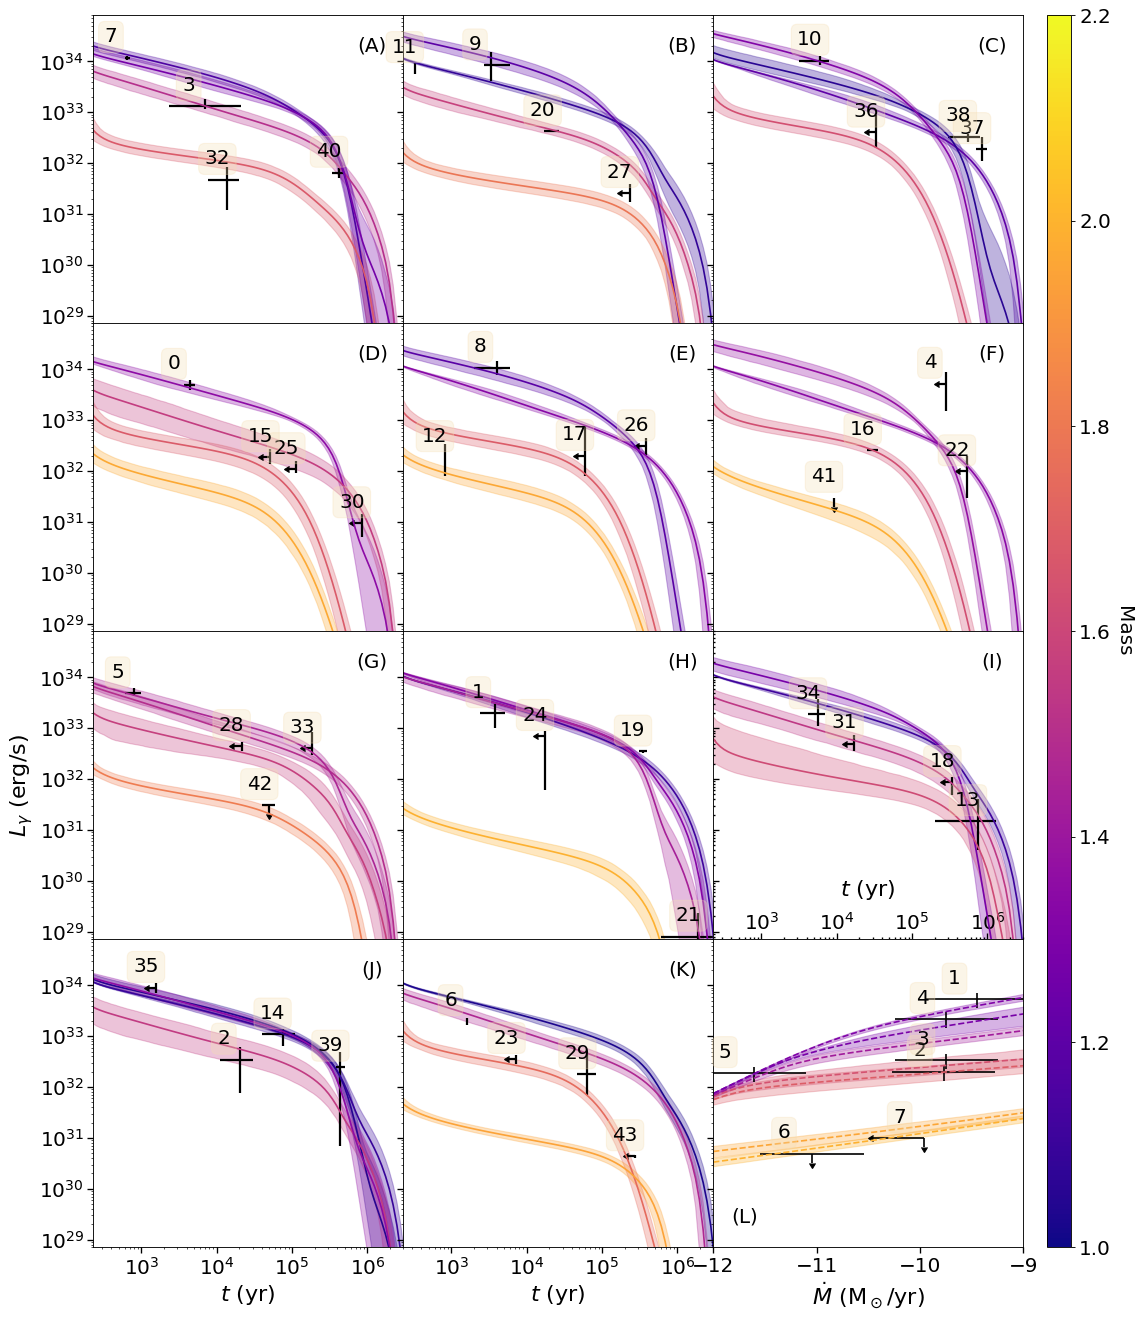

In [40]:
# Main file that will be used to plot the cooling curves
file_path='../kde_faja'
style=[':','--','-.']
letters = ['A','B','C','D','E','F','G','H','I','J','K','L']
# ---------------------------------------------------------------
# for 95% CI 
z_score=1.96
# ---------------------------------------------------------------

with h5py.File(file_path, 'r') as file:
    # Iterate over the indices to fill the array
    nlines = file['table']['nlines'][0]  # Number of rows present in the file
    dct = file['table']['data'] 
    Mns_max=dct['Mns_max']
    Mns_max_avg=np.mean(Mns_max)

    L_tensor = np.empty((nlines,3, 6, 100), dtype=np.float32)
    sL_tensor = np.empty((nlines,3, 6, 30), dtype=np.float32)

    for i, j, k in np.ndindex(3, 6, 100):
        L_tensor[:, i, j, k] = dct[f'cL_{i}_{j}_{k}'][:]

    for i, j, k in np.ndindex(3, 6, 30):
        sL_tensor[:, i, j, k] = dct[f'sL_{i}_{j}_{k}'][:]

    # Create a colormap using Plasma colormap on the mass grid
    colormap = plt.cm.plasma
    norm=plt.Normalize(1.0,2.2)
    sm=plt.cm.ScalarMappable(cmap=colormap,norm=norm)
    sm.set_array([])
    props = dict(boxstyle='round', edgecolor='wheat', facecolor='wheat', alpha=0.3)
    # ---------------------------------------------------------------

    # 12 subplots with shared y axis for luminosity
    fig, axes = plt.subplots(nrows=4, ncols=3, sharey=True, figsize=(15, 20),dpi=80,gridspec_kw={'hspace': 0, 'wspace': 0})
    axes=axes.flatten() # flatten the axis for easier indexing
    plt.ylim(7e28,8.0e34) # limit the luminosities for all subplots when sharey=True
    # ---------------------------------------------------------------
    lo=int(nlines/2.0-0.683/2.0*nlines)
    hi=int(nlines/2.0+0.683/2.0*nlines)

    # Plot the INS observed lum-age in 11 subplots
    for i in range(0,11):
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].set_xlim(2.3e2,3e6) # setting the xlims for each subplots as 12th subplot is different
        # Setting axis lables
        # ---------------------------------------------------------------
        if i==6:
            axes[i].set_ylabel(r'$ L_{\gamma}~(\mathrm{erg}/\mathrm{s}) $',fontsize=20)
        if i>8:
            axes[i].set_xlabel(r'$ t~(\mathrm{yr}) $',fontsize=20)
        # ---------------------------------------------------------------
        # Setting axis ticks for no overlap
        if i<8:
            labelbottom=False
        else:
            labelbottom=True
        # ---------------------------------------------------------------
        axes[i].tick_params(labelsize=18,width=1.2,length=5,labelbottom=labelbottom)
        axes[i].text(0.9,0.9,'(%s)' % letters[i],fontsize=18,ha='center',va='center',transform=axes[i].transAxes)
        # ---------------------------------------------------------------
        for this_name in name_list[i]:
            # Pick the average mass for this INS
            mf_ins=dct['mf_'+this_name]
            mf_ins_avg=np.mean(mf_ins)
            M_ins=mf_ins_avg*(Mns_max_avg-1)+1
            # Color according to the mass
            color=colormap(norm(M_ins))
            j=ins_names2.index(this_name)
            # ---------------------------------------------------------------
            # Check if they are upper limits stars
            t_upper_limit=(ins_data['data/t_upper_limit'][j]>0.5)
            L_upper_limit=(ins_data['data/L_upper_limit'][j]>0.5)
            # ---------------------------------------------------------------
            # set errors accordingly for age
            if t_upper_limit==True:
                t_cent=ins_data['data/t_sd'][j]
                t_err_low=t_cent*0.2
                t_err_high=t_cent*0.2
            elif abs(ins_data['data/t_kin'][j]>1.0e-5):
                t_cent=ins_data['data/t_kin'][j]
                t_err_low=t_cent-ins_data['data/t_kin_low'][j]
                t_err_high=ins_data['data/t_kin_high'][j]-t_cent
            elif abs(ins_data['data/t_kin_low'][j]>1.0e-5):
                t_cent=(ins_data['data/t_kin_high'][j]+
                        ins_data['data/t_kin_low'][j])/2.0
                t_err_low=(ins_data['data/t_kin_high'][j]-
                        ins_data['data/t_kin_low'][j])/2.0
                t_err_high=(ins_data['data/t_kin_high'][j]-
                        ins_data['data/t_kin_low'][j])/2.0
            # ---------------------------------------------------------------  
            # set errors accordingly for luminosity              
            if L_upper_limit==True:
                L_cent=ins_data['data/L_high'][j]
                L_err_low=L_cent*0.35
                L_err_high=L_cent*0.35
            elif abs(ins_data['data/L'][j]>1.0e-5):
                L_cent=ins_data['data/L'][j]
                L_err_low=L_cent-ins_data['data/L_low'][j]
                L_err_high=ins_data['data/L_high'][j]-L_cent
            elif abs(ins_data['data/L_low'][j]>1.0e-5):
                L_cent=(ins_data['data/L_high'][j]+
                        ins_data['data/L_low'][j])/2.0
                L_err_low=(ins_data['data/L_high'][j]-
                    ins_data['data/L_low'][j])/2.0
                L_err_high=(ins_data['data/L_high'][j]-
                        ins_data['data/L_low'][j])/2.0
            # ---------------------------------------------------------------
            # plot an errorbar for the star    
            if t_upper_limit==True:
                axes[i].errorbar(t_cent,L_cent,xerr=[[t_err_low],[t_err_high]],yerr=[[L_err_low],[L_err_high]],
                            xuplims=True,color='black',elinewidth=2.0)
            elif L_upper_limit==True:
                axes[i].errorbar(t_cent,L_cent,xerr=[[t_err_low],[t_err_high]],yerr=[[L_err_low],[L_err_high]],
                        uplims=True,color='black',elinewidth=2.0)
            else:
                axes[i].errorbar(t_cent,L_cent,xerr=[[t_err_low],[t_err_high]],yerr=[[L_err_low],[L_err_high]],
                        color='black',elinewidth=2.0)
            # ---------------------------------------------------------------
            # add text with the star name, position is subject to change for 
            # better visibility
            #if j%2:
            #  axes[i].text(t_cent*0.4,L_cent*2.0,this_name.replace('_','-'),
            #      fontsize=18,color=color,bbox=props)
            axes[i].text(t_cent*0.5,L_cent*2.0,j,
                 fontsize=18,color='black',bbox=props)
            #else:
            #  axes[i].text(t_cent*0.5,L_cent*0.5,this_name.replace('_','-'),
            #      fontsize=18,color=color,bbox=props)
            #  axes[i].text(t_cent*0.5,L_cent*0.3,j,
            #      fontsize=18,color='black',bbox=props)
                # ---------------------------------------------------------------

    # Plot the SXRT observed lum-mdot
    axes[8].tick_params(labelsize=18,width=1.2,labelbottom=True,direction='in',pad=-25,which='both')
    axes[8].set_xlabel(r'$ t~(\mathrm{yr}) $',fontsize=20,labelpad=-55)
    axes[11].tick_params(labelsize=18,width=1.2,length=5)
    axes[11].text(0.1,0.1,'(%s)' % (letters[11]),fontsize=18,ha='center',va='center',transform=axes[11].transAxes)
    axes[11].set_xlim(-12,-9)
    axes[11].set_yscale('log')
    axes[11].set_xlabel(r'$\dot M~(\mathrm{M_\odot/yr}) $',fontsize=20)
    for i in range(0,len(sxrt_data["data/index"])):
        this_name=sxrt_names[i]
        # Pick the average mass of the SXRT
        mf_ins=dct['mf_'+this_name]
        mf_ins_avg=np.mean(mf_ins)
        M_ins=mf_ins_avg*(Mns_max_avg-1)+1
        # Color according to the mass
        color=colormap(norm(M_ins))
        # ---------------------------------------------------------------
        # Plot the errorbars
        if (sxrt_data["data/t_upper_limit"][i]>0.5 and
                sxrt_data["data/L_upper_limit"][i]>0.5):
            axes[11].errorbar(np.log10(sxrt_data["data/M_dot"][i]),
                            sxrt_data["data/L_photon"][i],xerr=0.5,
                            yerr=sxrt_data["data/L_photon"][i]/3.0,
                            xuplims=True,uplims=True,color='black')
        elif sxrt_data["data/L_upper_limit"][i]>0.5:
            axes[11].errorbar(np.log10(sxrt_data["data/M_dot"][i]),
                            sxrt_data["data/L_photon"][i],xerr=0.5,
                            yerr=sxrt_data["data/L_photon"][i]/3.0,
                            uplims=True,color='black')
        else:
            axes[11].errorbar(np.log10(sxrt_data["data/M_dot"][i]),
                            sxrt_data["data/L_photon"][i],xerr=0.5,
                            yerr=sxrt_data["data/L_photon"][i]/3.0,
                            color='black')
        # ---------------------------------------------------------------
        # add texts, position subject to change
        #if i%2:
            #axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.03,sxrt_data["data/L_photon"][i]*2.0,this_name.replace('_','-'),
        axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.03,sxrt_data["data/L_photon"][i]*2.0,i+1,
                    fontsize=18,color='black',bbox=props)
        #else:
            #axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.02,sxrt_data["data/L_photon"][i]*0.4,this_name.replace('_','-'),
        #    axes[11].text(np.log10(sxrt_data["data/M_dot"][i])*1.02,sxrt_data["data/L_photon"][i]*0.4,i+1,
        #                fontsize=18,color='black',bbox=props)
        # ---------------------------------------------------------------
    ind=0
    # -------------------------------------------------------------------
    # Plot the cooling curves for INSs
    for i in range(0,11): 
        for this_name in name_list[i]:  
            # The list that will contain the cooling curves     
            result=[]
            for k in range(0,nlines):
                # for each row get the maximum mass and the mass and eta
                # of the star
                Mns_max=dct['Mns_max'][k]
                mf_ins=dct['mf_'+this_name][k]
                M_ins=mf_ins*(Mns_max-1)+1
                try:
                    eta_ins=dct['eta_'+this_name][k]
                except:
                    eta_ins=-17.0
                # ---------------------------------------------------------------
                # Add the cooling curve to the list
                result.append(mass_eta_interp(L_tensor[k],M_ins,eta_ins,100,this_name))
                    
            # Calculate the average cooling curve and 95%CI
            #res=np.mean(result,axis=0)
            miny=[]
            maxy=[]
            res=[]
            for l in range(0,100):
                result2=[sublist[l] for sublist in result]
                result2.sort()
                result2=result2[lo:hi]
                res.append(np.mean(result2))
                miny.append(min(result2))
                maxy.append(max(result2))
            # ---------------------------------------------------------------
            color=colormap(norm(M_ins))
            # plot the average Cooling curve and the 95%CI
            axes[i].plot(t_grid2,res,color=color)
            axes[i].fill_between(t_grid2,miny,maxy,alpha=0.3,color=color)
            ind+=1
            # ---------------------------------------------------------------
    
    # Plot the accretion curves for SXRTs
    for name in sxrt_names:
        result=[]
        for i in range(0,nlines):
            # for each row get the maximum mass and the mass and eta
            # of the star
            Mns_max=dct['Mns_max'][i]
            mf_ins=dct['mf_'+name][i]
            M_ins=mf_ins*(Mns_max-1)+1
            eta_ins=dct['eta_'+name][i]
            # ---------------------------------------------------------------
            # Add the accretion curve to the list
            result.append(mass_eta_interp(sL_tensor[i],M_ins,eta_ins,30,name))
        # Calculate the average accretion curve and 95%CI     
        miny=[]
        maxy=[]
        res=[]
        for l in range(0,30):
            result2=[sublist[l] for sublist in result]
            result2.sort()
            result2=result2[lo:hi]
            res.append(np.mean(result2))
            miny.append(min(result2))
            maxy.append(max(result2))
        # ---------------------------------------------------------------
        color=colormap(norm(M_ins))
        # plot the average accretion curve and the 95%CI
        axes[11].plot(mdot_grid2,res,linestyle='--',color=color)
        axes[11].fill_between(mdot_grid2,miny,maxy,alpha=0.3,color=color)
        # ---------------------------------------------------------------

# Add colorbar for mass
cax=fig.add_axes([0.92,0.11,0.02,0.77])
cbar=plt.colorbar(sm,cax=cax)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Mass',fontsize=18,rotation=270,labelpad=20)
#plt.savefig("../../nature/fig_compare/ins_aff.pdf", bbox_inches='tight')

plt.show()

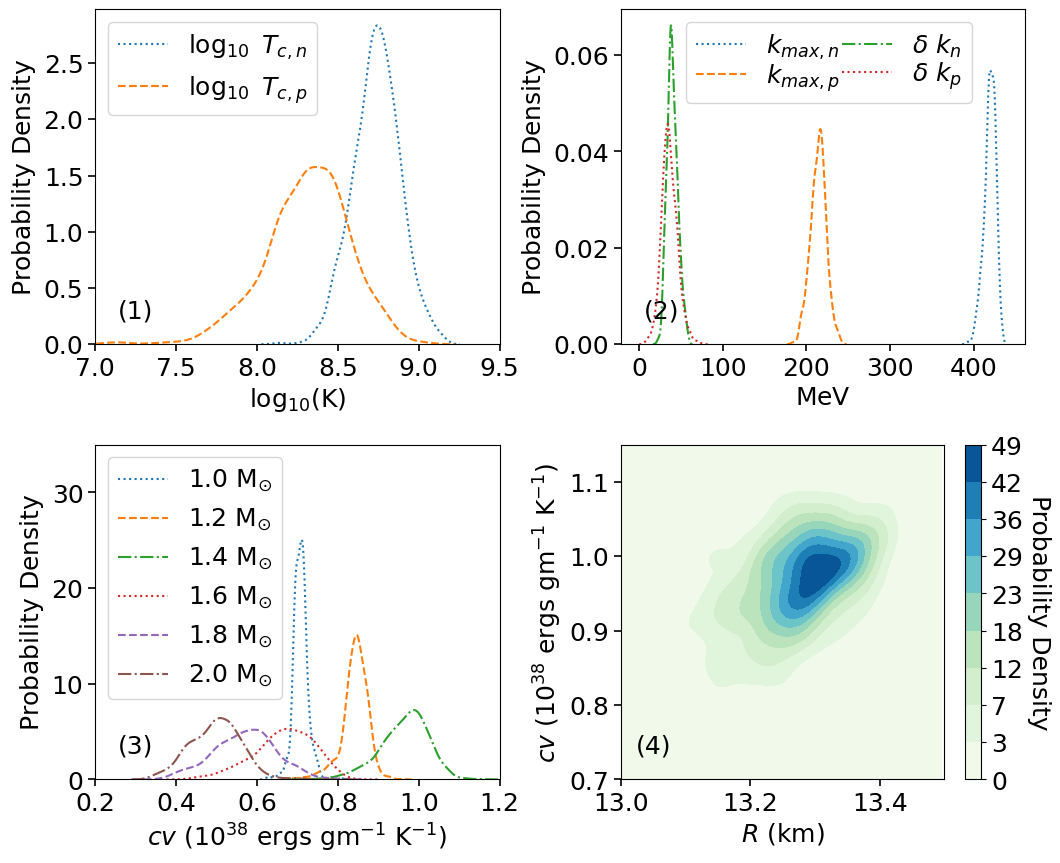

In [ ]:
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(12,10),gridspec_kw={'wspace':0.3,'hspace':0.3})
style=[':','--','-.']

with h5py.File('../kde_faja', 'r') as file:
    log10_Tcn=np.array(file['table']['data']['log10_Tcn'])
    log10_Tcp=np.array(file['table']['data']['log10_Tcp'])
    k_maxn=197.3*np.array(file['table']['data']['k_maxn']) # Convert fm^-1 to MeV
    k_maxp=197.3*np.array(file['table']['data']['k_maxp']) # Convert fm^-1 to MeV
    del_kn=197.3*np.array(file['table']['data']['del_kn']) # Convert fm^-1 to MeV
    del_kp=197.3*np.array(file['table']['data']['del_kp']) # Convert fm^-1 to MeV

    cv_0=np.array(file['table']['data']['cv_0'])
    cv_1=np.array(file['table']['data']['cv_1'])
    cv_2=np.array(file['table']['data']['cv_2'])
    cv_3=np.array(file['table']['data']['cv_3'])
    cv_4=np.array(file['table']['data']['cv_4'])
    cv_5=np.array(file['table']['data']['cv_5'])

    R_55=np.array(file['table']['data']['R_55'])

    # Make the subplots one by one
    sns.kdeplot(log10_Tcn,label=r'$\log_{10}~T_{c,n}$',ax=axes[0,0],linestyle=style[0])
    sns.kdeplot(log10_Tcp,label=r'$\log_{10}~T_{c,p}$',ax=axes[0,0],linestyle=style[1])
    axes[0,0].text(0.1,0.1,'(%i)' % (1),fontsize=18,ha='center',va='center',transform=axes[0,0].transAxes)
    axes[0,0].set_xlabel(r'$\mathrm{log_{10}(K)}$',fontsize=18)
    axes[0,0].set_ylabel(r'$\mathrm{Probability~Density}$',fontsize=18)
    axes[0,0].tick_params(labelsize=18,width=1.2,length=5)
    axes[0,0].set_xlim(7,9.5)
    axes[0,0].legend(fontsize=18)

    #axes[0,1].set_yscale('log')
    #axes[0,1].set_xscale('log')
    sns.kdeplot(k_maxn,label=r'$k_{max,n}$',ax=axes[0,1],linestyle=style[0])
    sns.kdeplot(k_maxp,label=r'$k_{max,p}$',ax=axes[0,1],linestyle=style[1])
    sns.kdeplot(del_kn,label=r'$\delta~k_n$',ax=axes[0,1],linestyle=style[2])
    sns.kdeplot(del_kp,label=r'$\delta~k_p$',ax=axes[0,1],linestyle=style[0])
    axes[0,1].text(0.1,0.1,'(%i)' % (2),fontsize=18,ha='center',va='center',transform=axes[0,1].transAxes)
    #axes[0,1].set_ylim(0,20)
    axes[0,1].set_xlabel(r'$\mathrm{MeV}$',fontsize=18)
    axes[0,1].set_ylabel(r'$\mathrm{Probability~Density}$',fontsize=18)
    axes[0,1].tick_params(labelsize=18,width=1.2,length=5)
    axes[0,1].legend(fontsize=18,loc='upper right', bbox_to_anchor=(0.9, 1.0),labelspacing=0.01,ncol=2,columnspacing=0.1)

    #axes[1,0].set_xscale('log')
    sns.kdeplot(cv_0*1e-38,label=r'$1.0~\mathrm{M}_{\odot}$',ax=axes[1,0],linestyle=style[0])
    sns.kdeplot(cv_1*1e-38,label=r'$1.2~\mathrm{M}_{\odot}$',ax=axes[1,0],linestyle=style[1])
    sns.kdeplot(cv_2*1e-38,label=r'$1.4~\mathrm{M}_{\odot}$',ax=axes[1,0],linestyle=style[2])
    sns.kdeplot(cv_3*1e-38,label=r'$1.6~\mathrm{M}_{\odot}$',ax=axes[1,0],linestyle=style[0])
    sns.kdeplot(cv_4*1e-38,label=r'$1.8~\mathrm{M}_{\odot}$',ax=axes[1,0],linestyle=style[1])
    sns.kdeplot(cv_5*1e-38,label=r'$2.0~\mathrm{M}_{\odot}$',ax=axes[1,0],linestyle=style[2])
    axes[1,0].legend(loc='upper left',fontsize=18)
    axes[1,0].text(0.1,0.1,'(%i)' % (3),fontsize=18,ha='center',va='center',transform=axes[1,0].transAxes)
    axes[1,0].set_xlabel(r'$cv~(10^{38}~\mathrm{ergs~gm^{-1}~K^{-1}})$',fontsize=18)
    axes[1,0].set_ylabel(r'$\mathrm{Probability~Density}$',fontsize=18)
    axes[1,0].tick_params(labelsize=18,width=1.2,length=5)
    #axes[1,0].set_yscale('log')
    axes[1,0].set_xlim(0.2,1.2)
    axes[1,0].set_ylim(0,35)

    #axes[1,1].set_yscale('log')
    kde=sns.kdeplot(x=R_55,y=cv_2*1e-38,fill=True, cmap='GnBu', thresh=0, label=r'$1.4~\mathrm{M}_{\odot}$',ax=axes[1,1])
    cbar=fig.colorbar(kde.collections[0],ax=axes[1,1])
    cbar.set_label('Probability Density',fontsize=18,rotation=270,labelpad=20)
    # Set the colorbar ticks manually
    #cbar.set_ticks([0, 50])
    #cbar.set_ticks(np.linspace(0, 50, num=5))  # Intermediate ticks
    ## Format ticks as integers using FuncFormatter
    from matplotlib.ticker import FuncFormatter
    formatter = FuncFormatter(lambda val, pos: f'{int(val)}')  # Converts the ticks to integers
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.tick_params(labelsize=18)
    axes[1,1].set_ylim(0.7,1.15)
    axes[1,1].set_xlim(13.0,13.5)
    axes[1,1].text(0.1,0.1,'(%i)' % (4),fontsize=18,ha='center',va='center',transform=axes[1,1].transAxes)
    axes[1,1].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
    axes[1,1].set_ylabel(r'$cv~(10^{38}~\mathrm{ergs~gm^{-1}~K^{-1}})$',fontsize=18)
    axes[1,1].tick_params(labelsize=18,width=1.2,length=5)
#plt.savefig('../../nature/fig_compare/sf_aff.pdf', bbox_inches='tight')
plt.show()

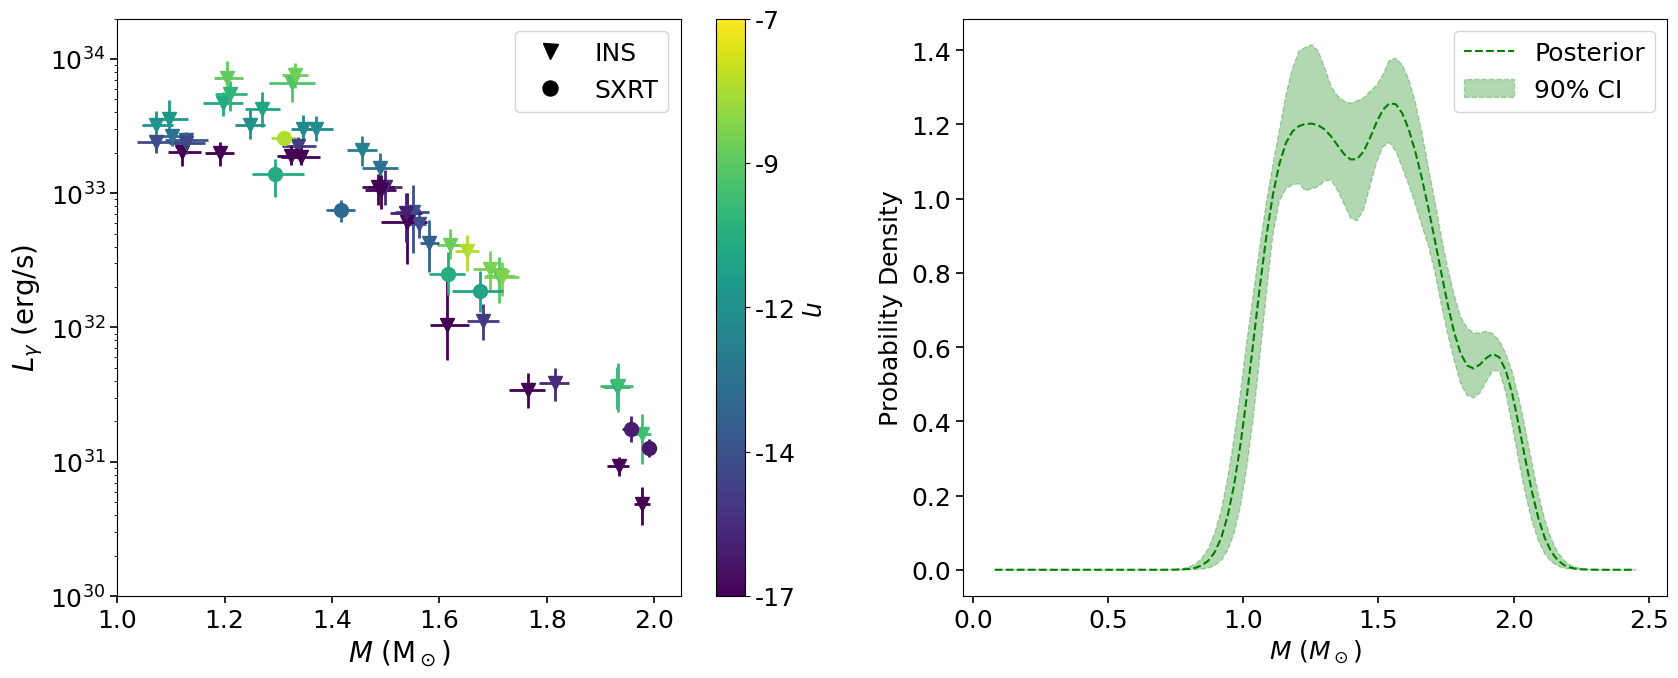

In [91]:
from scipy.stats import gaussian_kde
names=ins_names2+sxrt_names
m_grid=np.linspace(8.0e-2,2.45,100)
def mass_kde(name_list):
  y=[]
  for k in range(0,nlines):
    Mns_max=dct['Mns_max'][k]
    M=[]
    for name in name_list:
      try:
        mf_ins=dct['mf_'+name][k]
        M_ins=mf_ins*(Mns_max-1)+1
        M.append(M_ins)
      except:
        continue
      #print(name,M)
      #M_tot.append(np.mean(M))
    kde = gaussian_kde(M, bw_method=0.3)
    #kde = kdeplot.get_lines()[0]
    #x_temp = kde.get_xdata()
    y_temp = kde(m_grid)
    #ax.plot(m_grid,y_temp,ls=ls,color=col)
    #plt.hist(y_vals, bins=30, color='gray', alpha=0.7, edgecolor='black', label='KDE Density Values')
    y.append(y_temp)
  return y
  #axes.set_ylabel(r'$\mathrm{Probability~Density}$',fontsize=18)
  #axes.set_xlabel(r'$ Mass~(M_\odot)$',fontsize=18)
  #ax.legend(fontsize=18)
  #ax.tick_params(labelsize=18,width=1.2,length=5)

fig,axes=plt.subplots(nrows=1,ncols=2,figsize=(20,7.5),gridspec_kw={'wspace':0.2,'hspace':0.3})

# Main file that will be used to plot the cooling curves
file_path='../kde_faja'
# ---------------------------------------------------------------
# for 95% CI 
z_score=1.96
# ---------------------------------------------------------------
if(True):
  # Create a colormap using Plasma colormap
  colormap = plt.cm.viridis
  norm=plt.Normalize(-17.0,-7.0)
  sm=plt.cm.ScalarMappable(cmap=colormap,norm=norm)
  sm.set_array([])

  # Plot configuration
  #fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 12),dpi=80)
  axes[0].set_xlim(1.0,2.05)
  axes[0].set_ylim(1.0e30,2.0e34)
  axes[0].set_yscale('log')
  axes[0].set_ylabel(r'$ L_{\gamma}~(\mathrm{erg}/\mathrm{s}) $',fontsize=20)
  axes[0].set_xlabel(r'$ M~(\mathrm{M_\odot}) $',fontsize=20)
  axes[0].tick_params(labelsize=18,width=1.2,length=5)
  axes[0].plot(0.9,0.9,'v',label="INS",color='black')
  axes[0].plot(0.9,0.85,'o',label="SXRT",color='black')
  axes[0].legend(loc='upper right',fontsize=18,markerscale=1.8)
  # Add colorbar with \eta
  #cax=fig.add_axes([0.92,0.11,0.02,0.77])
  cbar=plt.colorbar(sm,ax=axes[0])
  # Set the colorbar ticks manually
  cbar.set_ticks([-17, -7])
  cbar.set_ticks(np.linspace(-17, -7, num=5))  # Intermediate ticks

  # Format ticks as integers using FuncFormatter
  from matplotlib.ticker import FuncFormatter
  formatter = FuncFormatter(lambda val, pos: f'{int(val)}')  # Converts the ticks to integers
  cbar.ax.yaxis.set_major_formatter(formatter)
  cbar.ax.tick_params(labelsize=18)
  cbar.set_label(r'$\eta$',fontsize=18,rotation=270,labelpad=20)

  names=ins_names2+sxrt_names

with h5py.File(file_path, 'r') as file:
  # Iterate over the indices to fill the array
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  dct = file['table']['data'] 
  Mns_max=dct['Mns_max']
  Mns_max_avg=np.mean(Mns_max)

  L_tensor = np.empty((nlines,3, 6, 100), dtype=np.float32)
  sL_tensor = np.empty((nlines,3, 6, 30), dtype=np.float32)

  for i, j, k in np.ndindex(3, 6, 100):
    L_tensor[:, i, j, k] = dct[f'cL_{i}_{j}_{k}'][:]

  for i, j, k in np.ndindex(3, 6, 30):
    sL_tensor[:, i, j, k] = dct[f'sL_{i}_{j}_{k}'][:]

  lo=int(nlines/2.0-0.683/2.0*nlines)
  hi=int(nlines/2.0+0.683/2.0*nlines)

  # Make the plot
  for name in names:
    result=[]
    mass=[]
    eta=[]
    for k in range(0,nlines):
        Mns_max=dct['Mns_max'][k]
        mf_ins=dct['mf_'+name][k]
        M_ins=mf_ins*(Mns_max-1)+1
        mass.append(M_ins)
        try:
            eta_ins=dct['eta_'+name][k]
        except:
            eta_ins=-17.0
        eta.append(eta_ins)
        if name in ins_names2:
            ret=mass_eta_interp(L_tensor[k],M_ins,eta_ins,100,name)
            result.append(ret[40])
        else:
            ret=mass_eta_interp(sL_tensor[k],M_ins,eta_ins,30,name)
            result.append(ret[20])
    color=colormap(norm(np.mean(eta)))
          
    result.sort()
    result=result[lo:hi]
    lum=np.mean(result)
    miny=min(result)
    maxy=max(result)
    mass.sort()
    mass=mass[lo:hi]
    ms=np.mean(mass)
    minx=min(mass)
    maxx=max(mass)
    if name in ins_names2:
        marker='v'
    else:
        marker='o'
    axes[0].errorbar(ms,lum,xerr=[[ms-minx],[maxx-ms]],yerr=[[lum-miny],[maxy-lum]],
                    color=color,elinewidth=2.0,fmt=marker,markersize=10)
    #axes.text(ms,lum,name)
    
#plt.savefig("../../nature/fig_compare/ml_kde.pdf", bbox_inches='tight')
#plt.show()

with h5py.File('../kde_faja', 'r') as file:
  # Import the data into a dictionary
  dct=file['table']['data']
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  y = mass_kde(ins_names2)
  lo=int(nlines/2.0-0.9/2.0*nlines)
  hi=int(nlines/2.0+0.9/2.0*nlines)

  miny_aff=[]
  maxy_aff=[]
  res_aff=[]
  for l in range(0,100):
      result2=[sublist[l] for sublist in y]
      result2.sort()
      result2=result2[lo:hi]
      res_aff.append(np.mean(result2))
      miny_aff.append(min(result2))
      maxy_aff.append(max(result2))
  axes[1].plot(m_grid,res_aff,color='green',ls='--',label='Posterior')
  axes[1].fill_between(m_grid,miny_aff,maxy_aff,color='green',ls='--',alpha=0.3,label='90% CI')
  axes[1].legend(fontsize=18)
  axes[1].set_ylabel(r'$\mathrm{Probability~Density}$',fontsize=18)
  axes[1].set_xlabel(r'$ M~(M_\odot)$',fontsize=18)
  axes[1].tick_params(labelsize=18,width=1.2,length=5)
  #plt.savefig('mass_2p.pdf', bbox_inches='tight')
  #0.2,0.3

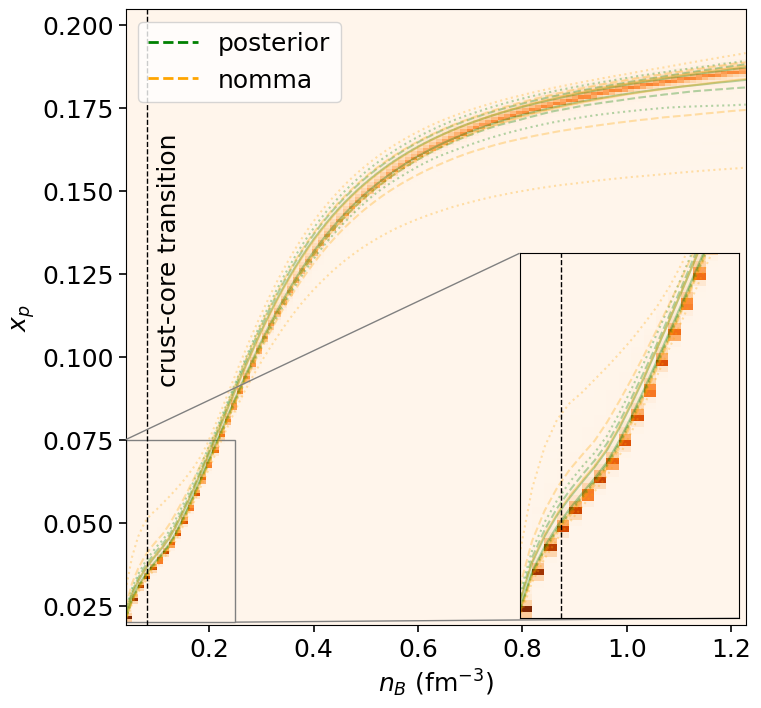

In [218]:
nB_grid=np.linspace(0.04, 1.228, 100)
fig, axes = plt.subplots(nrows=1,ncols=1,figsize=(8, 8))

with h5py.File('../kde_faja', 'r') as file:
# Iterate over the indices to fill the array
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  dct = file['table']['data'] 
  hist_t3d('xp',dct,nlines,axes,r'$n_B~(\mathrm{fm^{-3}})$',r'$x_p$',nB_grid,
    [100,200],['green','green','green'],'Greens',True)

with h5py.File('../noomma_tot_0_fix2_out', 'r') as file:
# Iterate over the indices to fill the array
  nlines = file['markov_chain_0']['nlines'][0]  # Number of rows present in the file
  dct = file['markov_chain_0']['data'] 
  hist_t3d('xp',dct,nlines,axes,r'$n_B~(\mathrm{fm^{-3}})$',r'$x_p$',nB_grid,
    [100,200],['orange','orange','orange'],'Oranges',True)

# Add the legend to the current axis
axes = plt.gca()  # Get current axes if not already defined
# Add vertical line at x = 0.08
axes.axvline(x=0.08, color='black', linestyle='--', linewidth=1)

# Add text next to the line
axes.text(0.1, 0.8, 'crust-core transition', rotation=90, color='black', fontsize=18,
        verticalalignment='top', horizontalalignment='left', transform=axes.get_xaxis_transform())
axes.plot([], [], color='green', linestyle='--', linewidth=2, label='posterior')
axes.plot([], [], color='orange', linestyle='--', linewidth=2, label='nomma')
axes.legend(loc='upper left', fontsize=18)  # Adjust loc as needed

# Create inset (zoomed-in area)
axins = zoomed_inset_axes(axes, zoom=2, loc='lower right')  # zoom factor, location
with h5py.File('../kde_faja', 'r') as file:
# Iterate over the indices to fill the array
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  dct = file['table']['data'] 
  hist_t3d('xp',dct,nlines,axins,r'$n_B~(\mathrm{fm^{-3}})$',r'$x_p$',nB_grid,
    [100,200],['green','green','green'],'Greens',True)

with h5py.File('../noomma_tot_0_fix2_out', 'r') as file:
# Iterate over the indices to fill the array
  nlines = file['markov_chain_0']['nlines'][0]  # Number of rows present in the file
  dct = file['markov_chain_0']['data'] 
  hist_t3d('xp',dct,nlines,axins,r'$n_B~(\mathrm{fm^{-3}})$',r'$x_p$',nB_grid,
    [100,200],['orange','orange','orange'],'Oranges',True)

# Set limits of zoom region
x1, x2 = 0.04, 0.25
y1, y2 = 0.02, 0.075
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
# Add vertical line at x = 0.08
axins.axvline(x=0.08, color='black', linestyle='--', linewidth=1)
# Remove ticks from inset
axins.set_xticks([])
axins.set_yticks([])
# Remove ticks and tick labels
axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Also clear axis labels (just in case)
axins.set_xlabel('')
axins.set_ylabel('')

# Draw a box and connecting lines
mark_inset(axes, axins, loc1=2, loc2=4, fc="none", ec="gray")

plt.savefig('../../../sroy/nature/fig_compare/xp_kde_nomma.pdf', bbox_inches='tight')
plt.show()

In [ ]:
qlmxb_names=['6304','6397','M13','M28','M30','wCen','X7','0030','J0740']
ins_list=[
        # upper left
        ['1E1207','J172054','J232327',
        'J061705','B1822','B0833','J185238'],
        ['J1740','J0726','J0720',
        'J0007','J1957','J0822','B0656'],
        # upper right
        ['J141256','J173203','J0205',
        'J0633_06','B1055','J1741','B1706'],
        ['J1119','B1727','B1823',
        'J085201','J160103','J181852','B2334'],
        ['J0357','J0633_17','J1357',
        'J2021','B1509','J1605','J1856'],
        ['B0114','B1951','J0538',
        'J1718','J104608','J1713','J1308','B0950','J0554']
]
# Create a figure with 8 subplots
fig, axes = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=True, figsize=(15, 15),gridspec_kw={'hspace': 0, 'wspace': 0})
# Flatten the 2D array of subplots to make indexing easier
axes = axes.flatten()

ax1 = axes[-1]  # Reference to the last subplot for labeling
# Iterate over each subplot
#m_grid=hr.h5read_name("../data/kde-jun-24/kde_jun_2_0_out",'mvsr_mass_grid')[0]
m_grid2=np.linspace(8.0e-2,2.45,100)
mcmc_data = hr.h5read_first_type("../data/kde-jun-24/kde_jun_2_0_out", 'table')
all_R = np.array([mcmc_data[f'data/R_{i}'][:] for i in range(100)])
avg_R = np.average(all_R, axis=1)
std_R = np.std(all_R, axis=1)
Mns_max = np.array(mcmc_data['data/Mns_max'])
Mns_max -= 1.0

for i in range(0,6):
    for j in range(0,len(ins_names2)):
        ins_name=ins_names2[j]
        if ins_name in ins_list[i]:
            M = np.multiply(np.array(mcmc_data['data/mf_'+ins_name]), Mns_max)
            M += 1.0
            avg_mf = np.average(M)
            std_mf = np.std(M)

            avg_Rns = np.average(np.array(mcmc_data['data/Rns_'+ins_name]))
            std_Rns = np.std(np.array(mcmc_data['data/Rns_'+ins_name]))

            if avg_mf > 1.85:
                color = 'black'
            elif 1.4 <= avg_mf <= 1.85:
                color = 'red'
            else:
                color = 'green'
            axes[i].tick_params(axis='both', which='both', labelsize=14)
            axes[i].errorbar(avg_Rns, avg_mf, xerr=[[std_Rns], [std_Rns]],
                  yerr=[[std_mf], [std_mf]], color=color,
                  label=r'%.2f %s' % (avg_mf, ins_name))
            axes[i].text(0.9, 0.1, '(%i)' % (i+1), fontsize=12, ha='center', va='center', transform=axes[i].transAxes)
            
    axes[i].legend(loc='lower left',fontsize=14)    


for j in range(0,len(sxrt_names)):
    sxrt_name=sxrt_names[j]
    M = np.multiply(np.array(mcmc_data['data/mf_'+sxrt_name]), Mns_max)
    M += 1.0
    avg_mf = np.average(M)
    std_mf = np.std(M)

    avg_Rns = np.average(np.array(mcmc_data['data/Rns_'+sxrt_name]))
    std_Rns = np.std(np.array(mcmc_data['data/Rns_'+sxrt_name]))

    if avg_mf > 1.85:
        color = 'black'
    elif 1.4 <= avg_mf <= 1.85:
        color = 'red'
    else:
        color = 'green'

    axes[6].tick_params(axis='both', which='both', labelsize=14)
    axes[6].errorbar(avg_Rns, avg_mf, xerr=[[std_Rns], [std_Rns]],
            yerr=[[std_mf], [std_mf]], color=color,
            label=r'%.2f %s' % (avg_mf, sxrt_name))
    axes[6].text(0.9, 0.1, '(7)', fontsize=12, ha='center', va='center', transform=axes[6].transAxes)
            
axes[6].legend(loc='lower left',fontsize=14) 

for j in range(0,len(qlmxb_names)):
    qlmxb_name=qlmxb_names[j]
    M = np.multiply(np.array(mcmc_data['data/mf_'+qlmxb_name]), Mns_max)
    M += 1.0
    avg_mf = np.average(M)
    std_mf = np.std(M)

    avg_Rns = np.average(np.array(mcmc_data['data/Rns_'+qlmxb_name]))
    std_Rns = np.std(np.array(mcmc_data['data/Rns_'+qlmxb_name]))

    if avg_mf > 1.85:
        color = 'black'
    elif 1.4 <= avg_mf <= 1.85:
        color = 'red'
    else:
        color = 'green'

    axes[7].tick_params(axis='both', which='both', labelsize=14)
    axes[7].errorbar(avg_Rns, avg_mf, xerr=[[std_Rns], [std_Rns]],
            yerr=[[std_mf], [std_mf]], color=color,
            label=r'%.2f %s' % (avg_mf, qlmxb_name))
    axes[7].text(0.9, 0.1, '(8)', fontsize=12, ha='center', va='center', transform=axes[7].transAxes)
            
axes[7].legend(loc='lower left',fontsize=14) 

for i_subplot, ax in enumerate(axes):
    # Access the 'R_i' values for the current subplot
    ax.set_ylim(0.9, 2.18)
    ax.set_xlim(11.8, 13.7)
    ax.plot(avg_R, m_grid2, color='orange',linestyle='dashed')
    ax.fill_betweenx(m_grid2, avg_R - std_R, avg_R + std_R, color='orange', alpha=0.3)
    

# Set xlabel for the last subplot
axes[0].set_ylabel("$ M~(\mathrm{M}_{\odot}) $", fontsize=14)
axes[3].set_ylabel("$ M~(\mathrm{M}_{\odot}) $", fontsize=14)
axes[6].set_ylabel("$ M~(\mathrm{M}_{\odot}) $", fontsize=14)
axes[-2].set_xlabel("$ R~(\mathrm{km}) $", fontsize=14)
axes[-3].set_xlabel("$ R~(\mathrm{km}) $", fontsize=14)
axes[-4].set_xlabel("$ R~(\mathrm{km}) $", fontsize=14)

# Adjust the layout of the entire figure
# Remove the last subplot
fig.delaxes(ax1)
plt.tight_layout()
plt.savefig("mr.pdf")
plt.show()

In [ ]:
# Import age and velocity oof stars from psr_vel.pdf
name_list=[
        ['1E1207','J172054','B2334','J1856'],
        ['J232327','B0833','J181852','B1822'],
        ['J1718','J0720','J1308','J185238'],
        ['J0822','J1740','J0007','J1957'],
        ['J173203','J1741','J0205','J0633_06'],
        ['J141256','J061705','B1055','J0554'],
        ['J0726','B1823','B0656','B1727'],
        ['J160103','J085201','B1706','J0633_17'],
        ['J1119','J0357','J0538','B0950'],
        ['B1509','J2021','J104608','J1605'],
        ['J1713','J1357','B1951','B0114']
    ]

# -------------------------------------------------------------------------
# 739   J1210-5226    zpst00     3.02e+08 * # 1E1207
# J172054 not found
# 3707  B2334+61      dtws85     4.06e+04 49.89
# 2692  J1856-3754    tm07       3.76e+06 251.26
# J232327 not found
# 438   B0833-45      lvm68      1.13e+04 76.97
# J181852 Not found
# 2274  B1822-09      dls72      J1825-0935    dls72      2.33e+05 22.49
# 1682  J1718-3718    hfs+04     J1718-3718    hfs+04     3.32e+04 *
# 370   J0720-3125    hmb+97     J0720-3125    hmb+97     1.9e+06  204.29
# 839   J1308+2127    hhss02     J1308+2127    hhss02     1.46e+06 *
# 2601  J1852+0040    ghs05      J1852+0040    ghs05      1.92e+08 *
# J0822 not found
# 1817  J1740+1000    mca00      J1740+1000    mca00      1.14e+05 *
# 3     J0007+7303    aaa+09c    J0007+7303    aaa+09c    1.39e+04 *
# 3355  J1957+5033    sdz+10     J1957+5033    sdz+10     8.38e+05 *
# J173203 not found
# 1831  J1741-2054    aaa+09c    J1741-2054    aaa+09c    3.86e+05 155.09
# 125   J0205+6449    mss+02     J0205+6449    mss+02     5.37e+03 22.76
# 337   J0633+0632    aaa+09c    J0633+0632    aaa+09c    5.92e+04 *
# 338   J0633+1746    hh92       J0633+1746    hh92       3.42e+05 151.94
# 976   J1412+7922    zhi+11     J1412+7922    zhi+11     2.8e+05  *
# J061705 not found
# 624   B1055-52      vl72       J1057-5226    vl72       5.35e+05 21.29
# 374   J0726-2612    bjd+06     J0726-2612    bjd+06     1.86e+05 *
# 2282  B1823-13      cl86       J1826-1334    cl86       2.14e+04 399.11
# 361   B0656+14      mlt+78     J0659+1414    mlt+78     1.11e+05 59.82
# 1753  B1727-47      lvw68      J1731-4744    lvw68      8.04e+04 500.59
# J160103 not found
# J085201 not found
# 1638  B1706-44      jlm+92     J1709-4429    jlm+92     1.75e+04 160.72
# 660   J1119-6127    ckl+00     J1119-6127    ckl+00     1.61e+03 *
# 176   J0357+3205    aaa+09c    J0357+3205    aaa+09c    5.4e+05  649.45
# 282   J0538+2817    fcwa95     J0538+2817    fcwa95     6.18e+05 356.77
# 1087  B1509-58      sh82       J1513-5908    sh82       1.57e+03 *
# 3432  J2021+3651    rhr+02     J2021+3651    rhr+02     1.72e+04 *
# J104608 not found
# 1279  J1605+3249    hab07      J1605+3249    hab07      *        *
# 1653  J1713-3949    cpkm02     J1713-3949    cpkm02     *        *
# 946   J1357-6429    lfl+06     J1357-6429    lfl+06     7.31e+03 *
# 3322  B1951+32      kcb+88     J1952+3252    kcb+88     1.07e+05 459.89
# 93    B0114+58      stwd85     J0117+5914    stwd85     2.75e+05 154.10
# 524   B0950+08      phbc68     J0953+0755    phbc68     1.75e+07 36.55
# 296   J0554+3107    pga+13     J0554+3107    pga+13     5.17e+04 *
# --------------------------------------------------------------------------
# J0822 16 ioffe d
# 1E 1207 35 ioffe d
# J232327 770+-40
# 
# --------------------------------------------------------------------------
v_B2234=49.89
v_J1856=251.26
v_B0833=76.97
v_B1822=22.49
v_J0720=204.29
v_J1741=155.09
v_J0205=22.76
v_J0633_17=151.94
v_B1055=21.29
v_B1823=399.11
v_B0656=59.82
v_B1727=500.59
v_B1706=160.72
v_J0357=649.45
v_J0538=356.77
v_B1951=459.89
v_B0114=154.10
v_B0950=36.55

# Load main file and get data into dictionary
filet=h5py.File('../data/kde_jun')
dct=filet['table']['data']
nlines = filet['table']['nlines'][0]  

# Plot configuration
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 12),dpi=80)
#axes.set_xlim(1.0,2.0)
#axes.set_ylim(1.0e30,8.0e34)
#axes.set_yscale('log')
axes.tick_params(labelsize=18,width=1.2,length=5)

# Create a colormap using Plasma colormap
colormap = plt.cm.plasma
norm=plt.Normalize(-17.0,-7.0)
sm=plt.cm.ScalarMappable(cmap=colormap,norm=norm)
sm.set_array([])

# Add colorbar with \eta
cax=fig.add_axes([0.92,0.11,0.02,0.77])
cbar=plt.colorbar(sm,cax=cax)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('$\eta$',fontsize=18)

axes.set_yscale('log')
axes.set_ylim(15,800)
# Make the plot
for name in ins_names2:
    mass=[]
    eta=[]
    for k in range(0,nlines):
        Mns_max=dct['Mns_max'][k]
        mf_ins=dct['mf_'+name][k]
        M_ins=mf_ins*(Mns_max-1)+1
        mass.append(M_ins)
        try:
            eta.append(dct['eta_'+name][k])
        except:
            eta.append(-17.0)
    
    M_avg=np.mean(mass)
    eta_avg=np.mean(eta)
    M_std=np.std(mass)
    color=colormap(norm(eta_avg))
    try:
        axes.errorbar(M_avg,eval('v_'+name),xerr=M_std,fmt='o',color=color)
        #axes.text(M_avg,eval('v_'+name),name)
    except:
        continue
axes.set_xlabel('$\mathrm{Mass~(M_\odot)}$')
axes.set_ylabel('$\mathrm{velocity~(km/s)}$')

In [ ]:
from scipy.stats import gaussian_kde
#QLMXB PLOTS
qlmxb_names=['6304','6397','M13','M28','M30','wCen','X7','0030','J0740']

# Main file that will be used to plot the cooling curves
file_path='../data/kde_faja'
# ---------------------------------------------------------------
def ret_MR(name,atm,nlines,dct):
    M=[]
    R=[]
    if atm=='H':
        for k in range(0,nlines):
            Mns_max=dct['Mns_max'][k]
            mf_star=dct['mf_'+name][k]
            Mns_star=mf_star*(Mns_max-1)+1
            eta_star=dct['eta_'+name][k]
            Rns_star=dct['Rns_'+name][k]
            if eta_star<2/3: # Change this to switch from H to He and vice versa
                M.append(Mns_star)
                R.append(Rns_star)
    elif atm=='He':
        for k in range(0,nlines):
            Mns_max=dct['Mns_max'][k]
            mf_star=dct['mf_'+name][k]
            Mns_star=mf_star*(Mns_max-1)+1
            eta_star=dct['eta_'+name][k]
            Rns_star=dct['Rns_'+name][k]
            if eta_star>2/3: # Change this to switch from H to He and vice versa
                M.append(Mns_star)
                R.append(Rns_star)
    else:
        for k in range(0,nlines):
            Mns_max=dct['Mns_max'][k]
            mf_star=dct['mf_'+name][k]
            Mns_star=mf_star*(Mns_max-1)+1
            eta_star=dct['eta_'+name][k]
            Rns_star=dct['Rns_'+name][k]
            M.append(Mns_star)
            R.append(Rns_star)

    return M,R
# ---------------------------------------------------------------
def den_cont(name,a,b,ax):
    # Create a grid for the KDE
    x_grid = np.linspace(np.min(a), np.max(a), 100)
    y_grid = np.linspace(np.min(b), np.max(b), 100)
    X, Y = np.meshgrid(x_grid, y_grid)

    # Compute the KDE
    positions = np.vstack([X.ravel(), Y.ravel()])
    kde = gaussian_kde([a, b])
    Z = kde(positions).reshape(X.shape)

    style=[':','--','-']
    clrs=['orange','magenta','purple']

    # Calculate the contours for confidence intervals
    conf_intervals = [0.68, 0.90, 0.99]
    thresholds = [np.percentile(Z.flatten(), conf * 100) for conf in conf_intervals]

    # Create the 2D KDE plot
    sns.kdeplot(x=a, y=b, fill=True, cmap='GnBu', thresh=0, levels=25, cbar=True, ax=ax)

    # Customize the color bar ticks
    cbar = ax.collections[0].colorbar
    #cbar.set_ticks([0.1, 0.3, 0.5, 0.7, 0.9])
    cbar.ax.tick_params(labelsize=18)  # Set the font size of the color bar ticks

    # Overlay the confidence intervals as contours
    for i, conf in enumerate(conf_intervals):
        ax.contour(X, Y, Z, levels=[thresholds[i]], linewidths=1, linestyles=style[i], 
             colors=clrs[i])
    ax.tick_params(labelsize=18,width=1.2,length=5)
    ax.text(0.2,0.9,name,fontsize=18,ha='center',va='center',color='purple',transform=ax.transAxes)

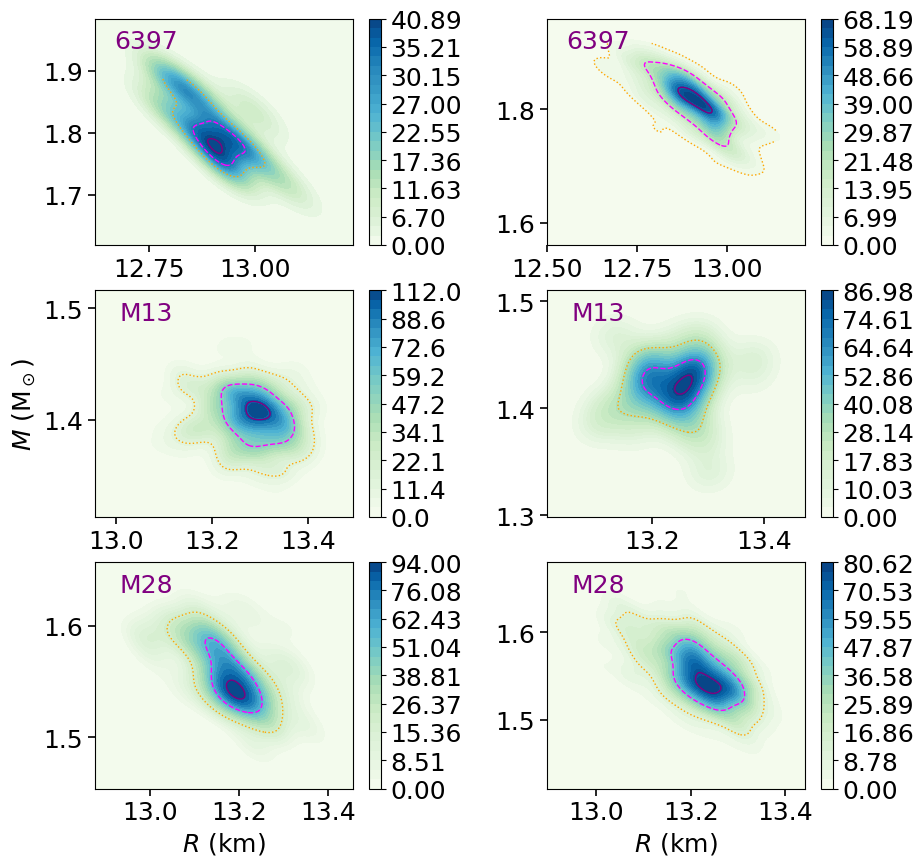

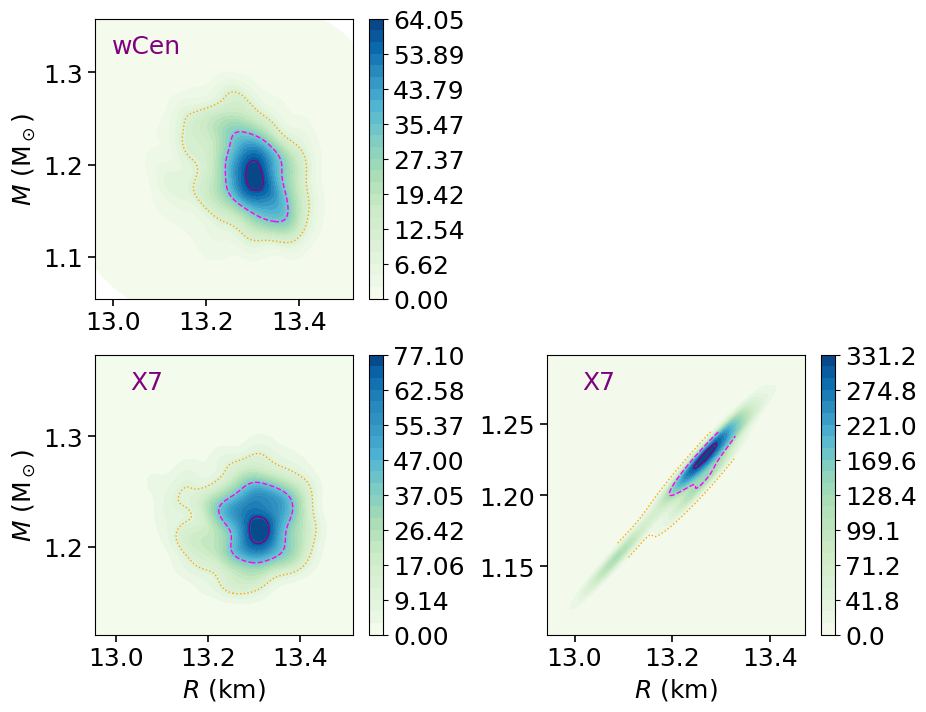

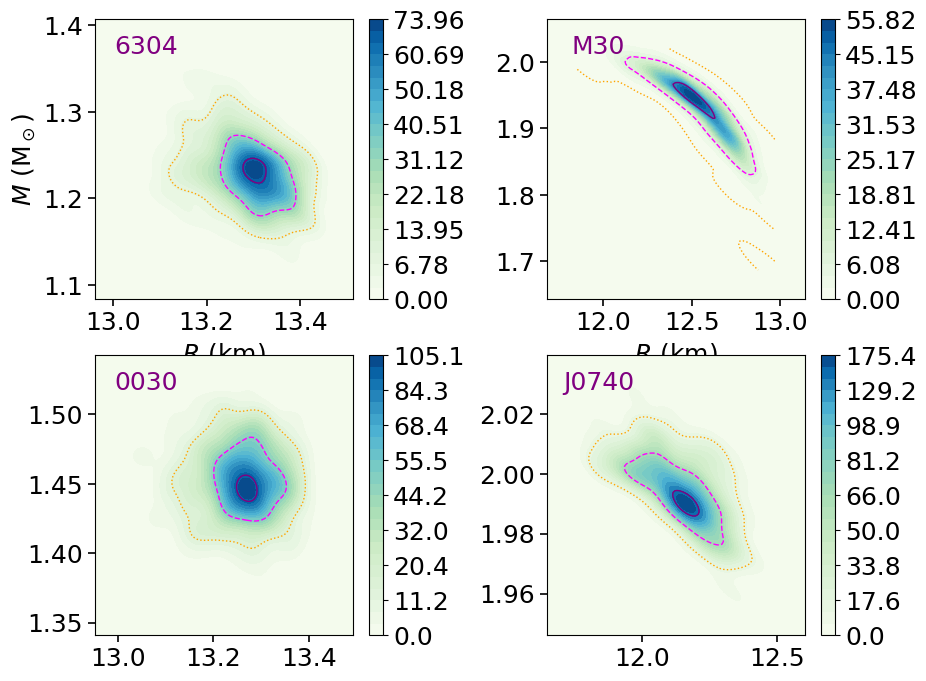

In [10]:
file_path='../data/kde_faja'
with h5py.File(file_path, 'r') as file:
    nlines = file['table']['nlines'][0]  # Number of rows present in the file
    dct = file['table']['data'] 
    # 12 subplots with shared y axis for luminosity
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10),gridspec_kw={'wspace': 0.4})
    axes=axes.flatten() # flatten the axis for easier indexing
    axes[4].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
    axes[5].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
    axes[2].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)
    # Iterate over the indices to fill the array
    M,R=ret_MR('6397','H',nlines,dct)
    den_cont('6397',R,M,axes[0])
    M,R=ret_MR('6397','He',nlines,dct)
    den_cont('6397',R,M,axes[1])
    M,R=ret_MR('M13','H',nlines,dct)
    den_cont('M13',R,M,axes[2])
    M,R=ret_MR('M13','He',nlines,dct)
    den_cont('M13',R,M,axes[3])
    M,R=ret_MR('M28','H',nlines,dct)
    den_cont('M28',R,M,axes[4])
    M,R=ret_MR('M28','He',nlines,dct)
    den_cont('M28',R,M,axes[5])
    plt.savefig("qlmxb_post_1.pdf", bbox_inches='tight')

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8),gridspec_kw={'wspace': 0.4})
    axes=axes.flatten() # flatten the axis for easier indexing
    axes[2].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
    axes[3].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
    axes[2].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)
    axes[0].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)

    M,R=ret_MR('wCen','Huhu',nlines,dct)
    den_cont('wCen',R,M,axes[0])
    #M,R=ret_MR('wCen','He',nlines,dct)
    #den_cont('wCen',R,M,axes[1])
    M,R=ret_MR('X7','H',nlines,dct)
    den_cont('X7',R,M,axes[2])
    M,R=ret_MR('X7','He',nlines,dct)
    den_cont('X7',R,M,axes[3])
    fig.delaxes(axes[1])
    
    plt.savefig("qlmxb_post_2.pdf", bbox_inches='tight')

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8),gridspec_kw={'wspace': 0.4})
    axes=axes.flatten() # flatten the axis for easier indexing
    axes[0].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
    axes[1].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
    axes[0].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)

    M,R=ret_MR('6304','H',nlines,dct)
    den_cont('6304',R,M,axes[0])
    M,R=ret_MR('M30','He',nlines,dct)
    den_cont('M30',R,M,axes[1])
    M,R=ret_MR('0030',None,nlines,dct)
    den_cont('0030',R,M,axes[2])
    M,R=ret_MR('J0740',None,nlines,dct)
    den_cont('J0740',R,M,axes[3])
    plt.savefig("qlmxb_post_3.pdf", bbox_inches='tight')

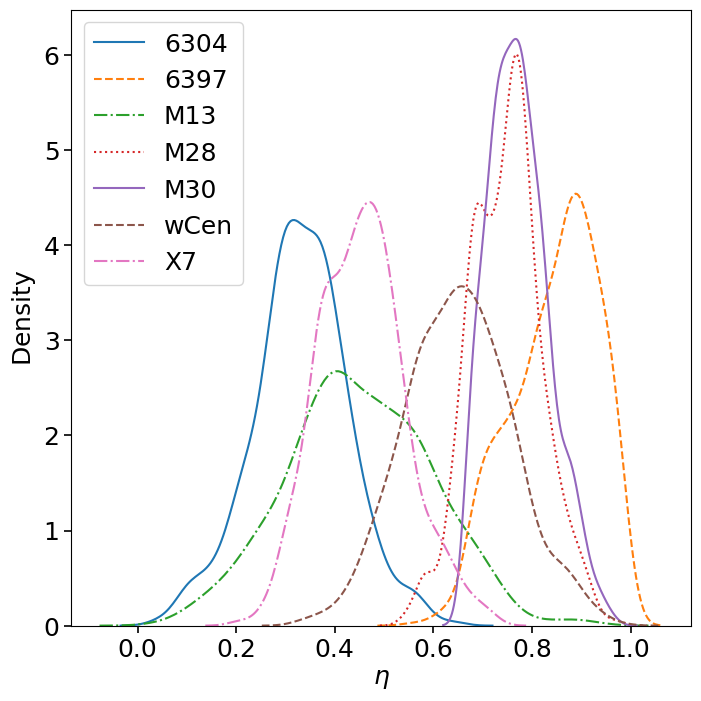

In [3]:
#QLMXB PLOTS
qlmxb_names=['6304','6397','M13','M28','M30','wCen','X7']
linestyle=['-','--','-.',':']

# Main file that will be used to plot the cooling curves
file_path='../data/kde_faja'
# ---------------------------------------------------------------
# 12 subplots with shared y axis for luminosity
fig, axes = plt.subplots(figsize=(8, 8))
axes.set_xlabel(r'$\eta$',fontsize=18)
axes.set_ylabel(r'$\mathrm{Density}$',fontsize=18)
axes.tick_params(labelsize=18,width=1.2,length=5)
with h5py.File(file_path, 'r') as file:  
    for i in range (0,len(qlmxb_names)):
        name=qlmxb_names[i]
        eta=np.array(file['table']['data']['eta_'+name])
        sns.kdeplot(eta,label=name, linestyle=linestyle[i%4])
    axes.legend(loc='upper left',fontsize=18)
plt.savefig("qlmxb_atm.pdf")
plt.show()

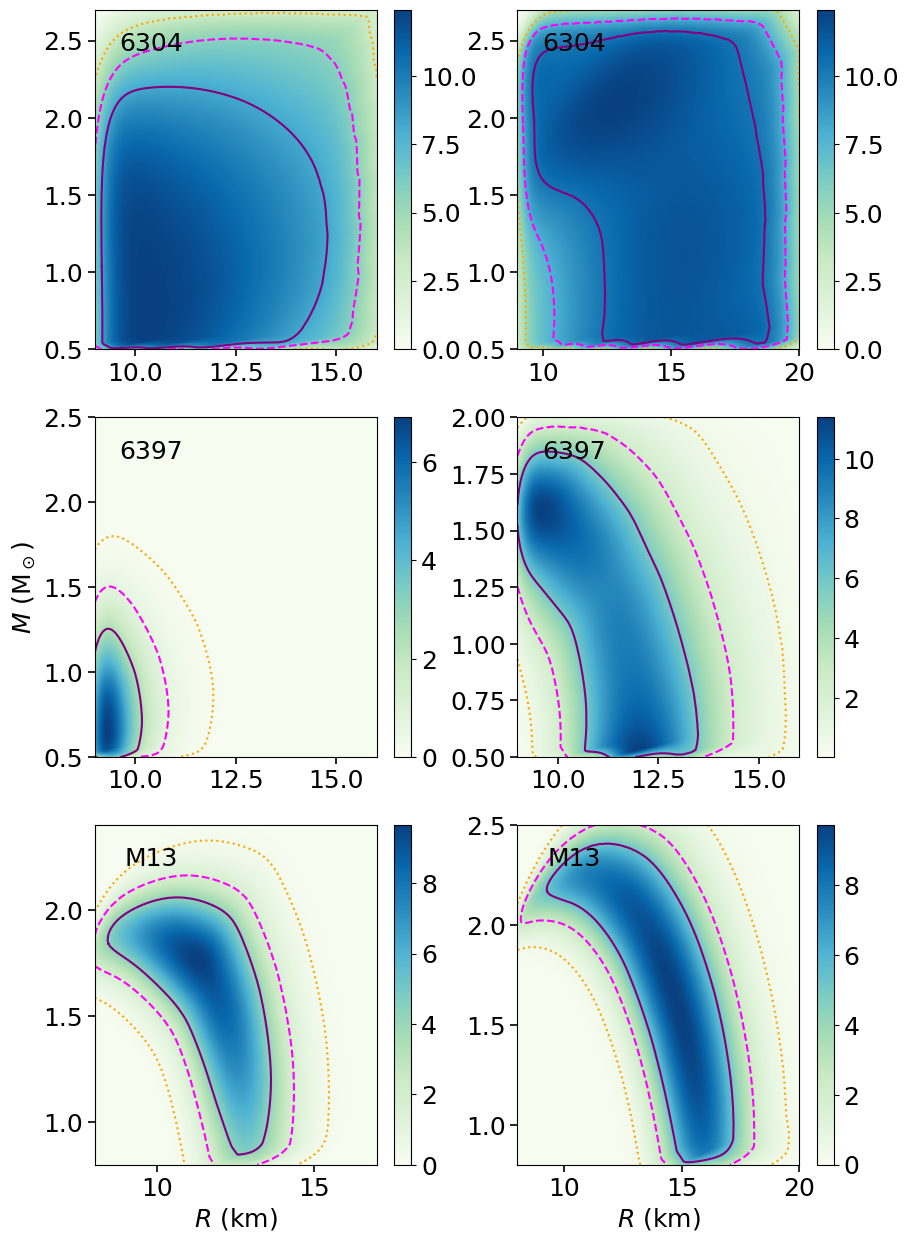

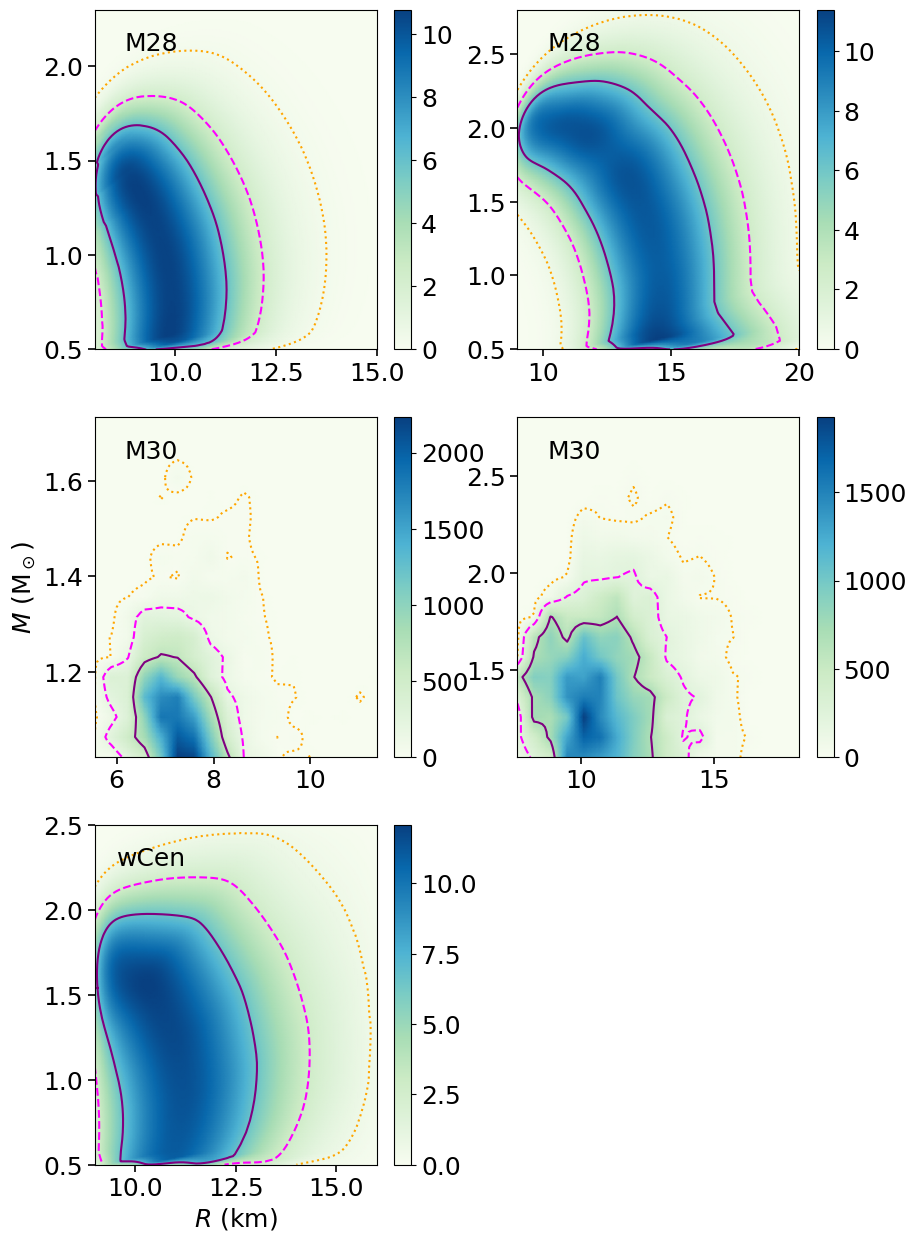

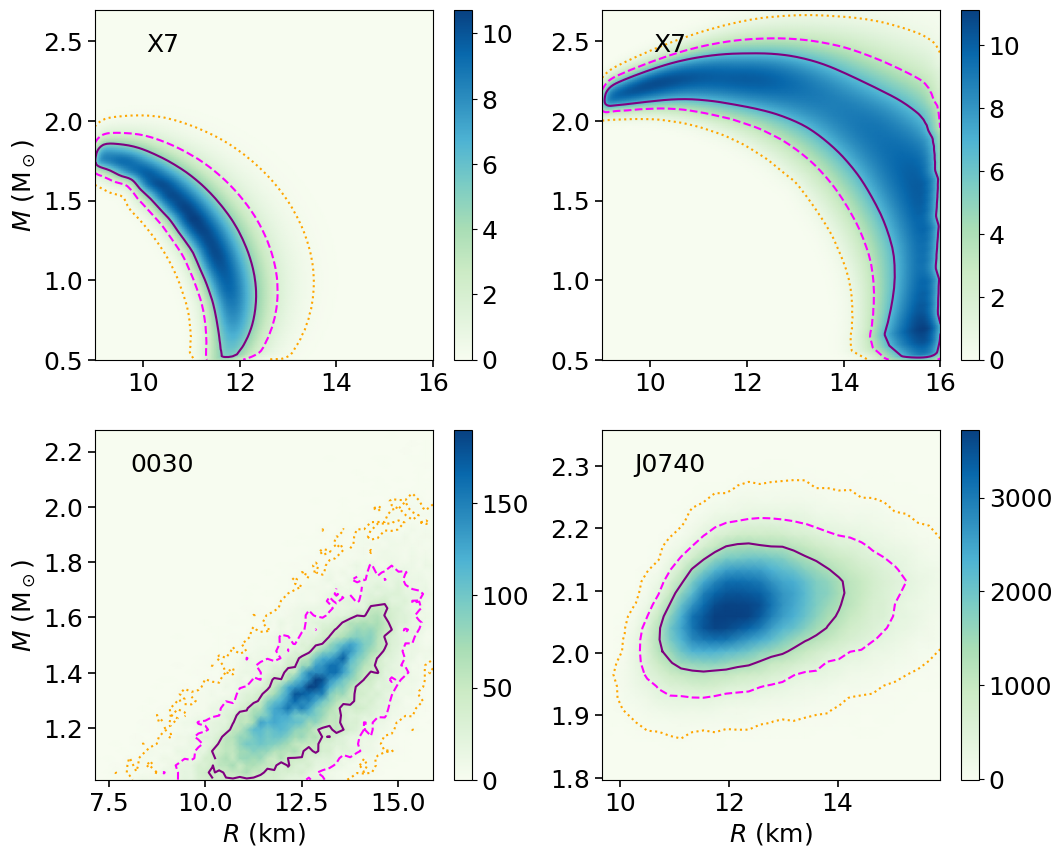

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
hr=hdf5_reader()

struct_data=[['6304','../qlmxb/6304_H_nopl_syst_wilm.o2',
              '../qlmxb/6304_He_nopl_syst_wilm.o2','rescaled','like'],
             ['6397','../qlmxb/6397_H_syst_wilm.o2',
              '../qlmxb/6397_He_syst_wilm3.o2','rescaled','like'],
             ['M13','../qlmxb/M13_H_rs.o2',
              '../qlmxb/M13_He_rs.o2','rescaled_0','like'],
             ['M28','../qlmxb/M28_H_syst_wilm.o2',
              '../qlmxb/M28_He_syst_wilm.o2','rescaled','like'],
             ['M30','../qlmxb/M30_echi_atmos.o2',
              '../qlmxb/M30_echi_x.o2','rescaled','like'],
             ['wCen','../qlmxb/wCen_H_syst_wilm.o2',
              '../qlmxb/wCen_H_syst_wilm.o2','rescaled','like'],
             ['X7','../qlmxb/X7_H_syst_wilm.o2',
              '../qlmxb/X7_He_syst_wilm.o2','rescaled','like'],
             ['0030','../nicer/0030_st_pst.o2',
              '../nicer/0030_st_pst.o2','table3d','prob'],
              ['J0740','../NICERxXMM/J0740_H_MR_t3d.o2',
              '../NICERxXMM/J0740_H_MR_t3d.o2','table3d','prob']]

contour_data=['c68','c90','c99']
style=['-','--',':']
clrs=['purple','magenta','orange']

def den_plot(name,file_name,t1,t2,ax):
    ax.tick_params(labelsize=18,width=1.2,length=5)
    ax.text(0.2,0.9,name,fontsize=18,ha='center',va='center',color='black',transform=ax.transAxes)
    with h5py.File(file_name, 'r') as file:
        Z=np.array(file[t1]['data'][t2])
        Z=Z.transpose()
        M_grid=file[t1]['yval'][:]
        R_grid=file[t1]['xval'][:]
        dim=len(M_grid)
        for c in range(0,3):
            contours=hr.h5read_name(file_name,contour_data[c])[0]
            n_cont=contours['n_lines'][0]
            for j in range(0,n_cont):
                cont_line_x=contours['line_'+str(j)+'/x']
                cont_line_y=contours['line_'+str(j)+'/y']
                tx=[cont_line_x[i] for i in range(0,len(cont_line_x))]
                ty=[cont_line_y[i] for i in range(0,len(cont_line_y))]
                ax.plot(tx,ty,color=clrs[c],ls=style[c])
        mesh=ax.pcolormesh(R_grid,M_grid,Z,rasterized=True,shading='gouraud',cmap='GnBu')
        # Add a colorbar
        cbar = plt.colorbar(mesh)
        cbar.ax.tick_params(labelsize=18)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
axes=axes.flatten() # flatten the axis for easier indexing
axes[4].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
axes[5].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
axes[2].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)

for i in range(0,3):
    den_plot(struct_data[i][0],struct_data[i][1],struct_data[i][3],struct_data[i][4],axes[i*2])
    den_plot(struct_data[i][0],struct_data[i][2],struct_data[i][3],struct_data[i][4],axes[i*2+1])
plt.savefig("qlmxb_prior_1.pdf", bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
axes=axes.flatten() # flatten the axis for easier indexing
axes[4].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
axes[5].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
axes[2].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)


den_plot(struct_data[3][0],struct_data[3][1],struct_data[3][3],struct_data[3][4],axes[(3-3)*2])
den_plot(struct_data[3][0],struct_data[3][2],struct_data[3][3],struct_data[3][4],axes[(3-3)*2+1])
den_plot(struct_data[4][0],struct_data[4][1],struct_data[4][3],struct_data[4][4],axes[(4-3)*2])
den_plot(struct_data[4][0],struct_data[4][2],struct_data[4][3],struct_data[4][4],axes[(4-3)*2+1])
den_plot(struct_data[5][0],struct_data[5][1],struct_data[5][3],struct_data[5][4],axes[(5-3)*2])
    #den_plot(struct_data[i][0],struct_data[i][2],struct_data[i][3],struct_data[i][4],axes[(i-3)*2+1])
fig.delaxes(axes[5])
plt.savefig("qlmxb_prior_2.pdf", bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes=axes.flatten() # flatten the axis for easier indexing
axes[2].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
axes[3].set_xlabel(r'$R~(\mathrm{km})$',fontsize=18)
axes[0].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)
axes[2].set_ylabel(r'$M~(\mathrm{M_\odot})$',fontsize=18)


den_plot(struct_data[6][0],struct_data[6][1],struct_data[6][3],struct_data[6][4],axes[0])
den_plot(struct_data[6][0],struct_data[6][2],struct_data[6][3],struct_data[6][4],axes[1])
den_plot(struct_data[7][0],struct_data[7][1],struct_data[7][3],struct_data[7][4],axes[2])
den_plot(struct_data[8][0],struct_data[8][1],struct_data[8][3],struct_data[8][4],axes[3])
plt.savefig("qlmxb_prior_3.pdf", bbox_inches='tight')
plt.show()

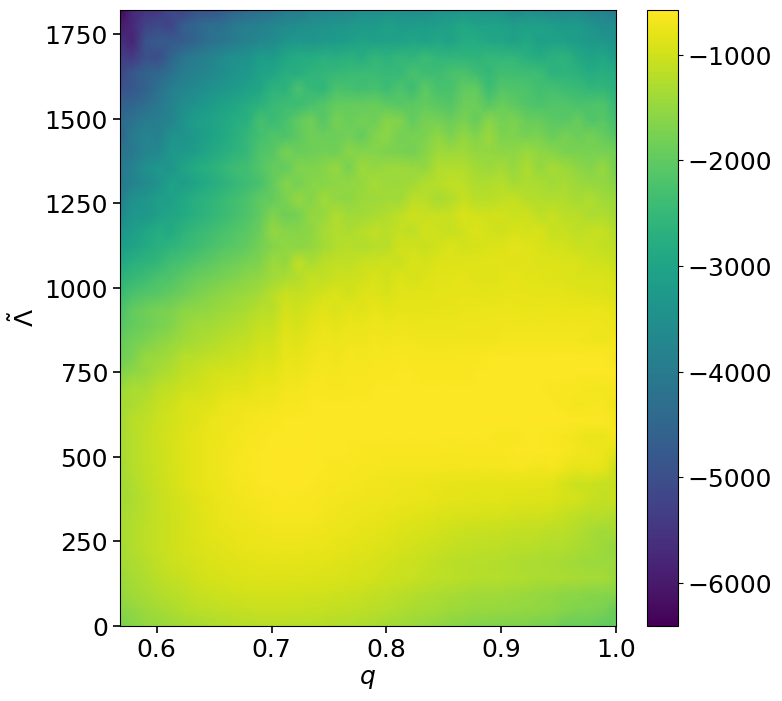

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
axes.set_xlabel(r'$q$',fontsize=18)
axes.set_ylabel(r'$\tilde \Lambda$',fontsize=18)
axes.tick_params(labelsize=18,width=1.2,length=5)
with h5py.File('q_lt.o2', 'r') as file:
  q=file['kde_log_prob']['xval'][:]
  lambdat=file['kde_log_prob']['yval'][:]
  prob=np.array(file['kde_log_prob']['data']['prob'])
  prob=prob.transpose()
  mesh=plt.pcolormesh(q,lambdat,prob,shading='gouraud')
  cbar = plt.colorbar(mesh)
  cbar.ax.tick_params(labelsize=18)
  plt.savefig('ligo_pri.pdf')

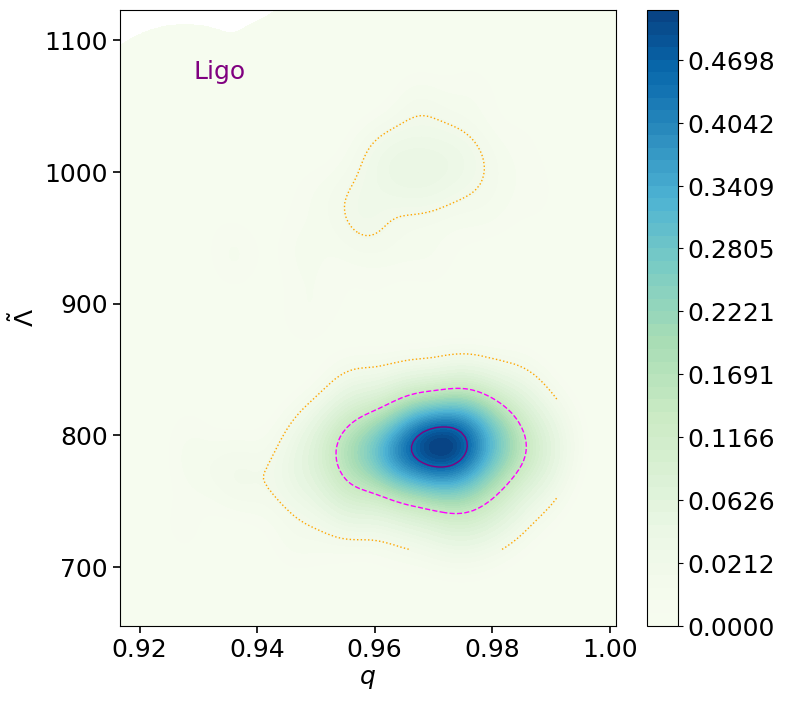

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
axes.set_xlabel(r'$q$',fontsize=18)
axes.set_ylabel(r'$\tilde \Lambda$',fontsize=18)
axes.tick_params(labelsize=18,width=1.2,length=5)
with h5py.File('../data/kde_faja', 'r') as file:
  # Iterate over the indices to fill the array
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  dct = file['table']['data'] 
  q=[]
  lambdat=[]
  for k in range(0,nlines):
    q.append(dct['q'][k])
    lambdat.append(dct['Lambdat'][k])

  den_cont('Ligo',q,lambdat,axes)
  plt.savefig('ligo_post.pdf')

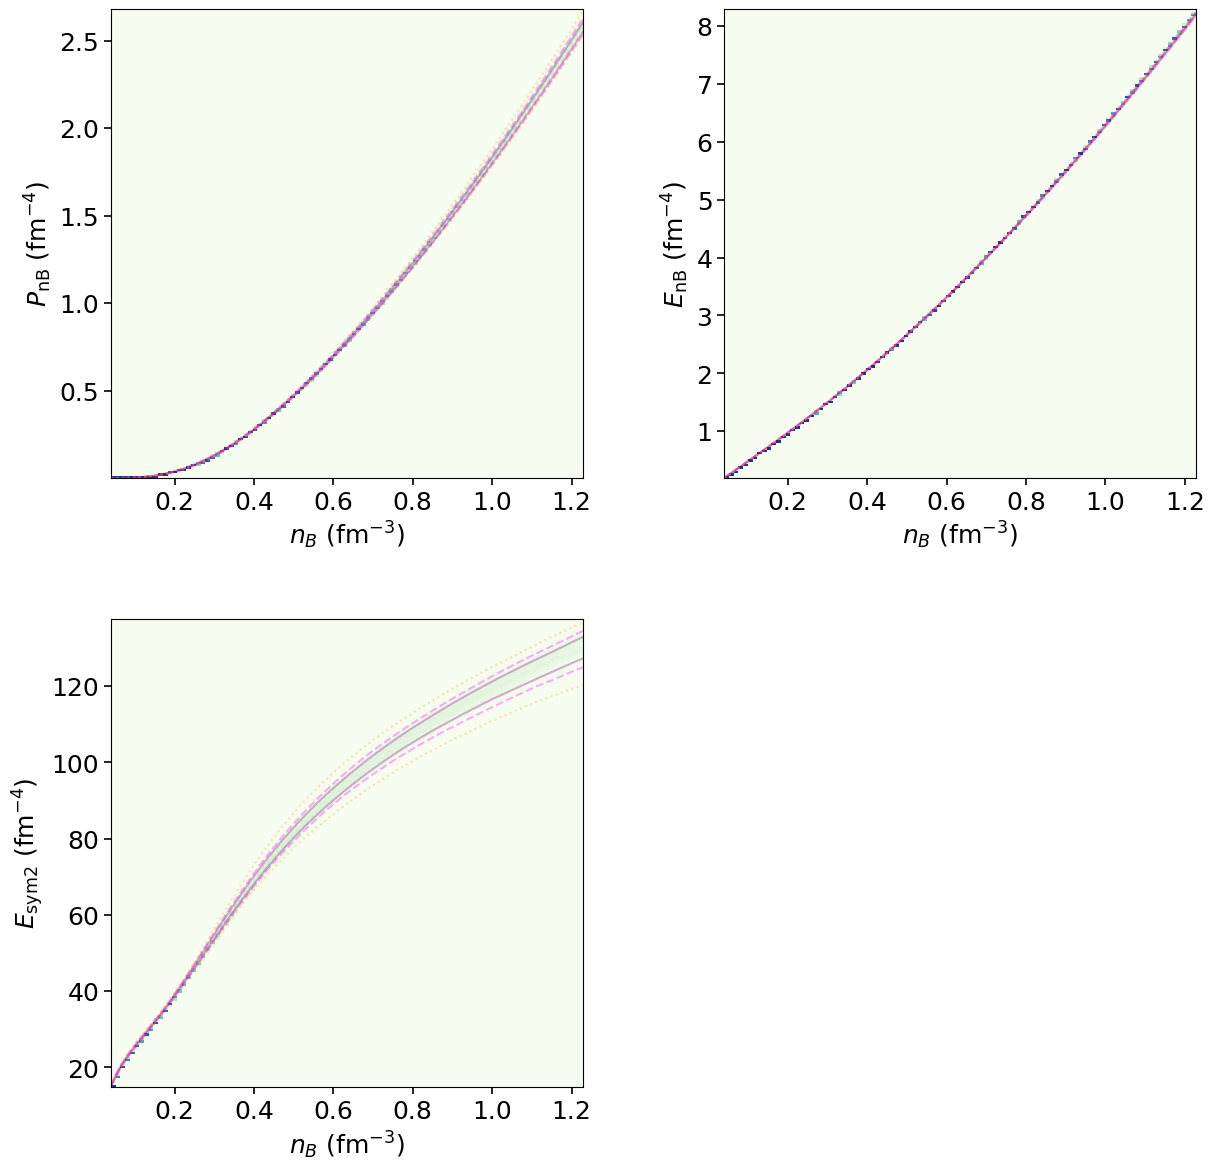

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 14),gridspec_kw={'hspace': 0.3, 'wspace': 0.3})
axes=axes.flatten()
nB_grid=np.linspace(0.04,1.228,100)

with h5py.File('../kde_faja', 'r') as file:
  # Iterate over the indices to fill the array
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  dct = file['table']['data'] 
  clrs = ['purple','magenta','orange']
  cmp = 'GnBu'

  hist_t3d('Pnb',dct,nlines,axes[0],r'$P_{\mathrm{nB}}~(\mathrm{fm^{-4}})$',clrs,cmp)
  hist_t3d('Enb',dct,nlines,axes[1],r'$E_{\mathrm{nB}}~(\mathrm{fm^{-4}})$',clrs,cmp)
  #hist_t3d('Esym',dct,nlines,axes[2],r'$E_{\mathrm{sym}}~(\mathrm{fm^{-4}})$',clrs,cmp)
  hist_t3d('Esym2',dct,nlines,axes[2],r'$E_{\mathrm{sym2}}~(\mathrm{fm^{-4}})$',clrs,cmp)
  fig.delaxes(axes[3])
  #hist_t3d('cs2',dct,nlines,axes[4],r'$c_s^2$',clrs,cmp)
  #hist_t3d('xp',dct,nlines,axes[5],r'$x_p~(\mathrm{fm^{-4}})$',clrs,cmp)
  plt.savefig('eos_nB.pdf')

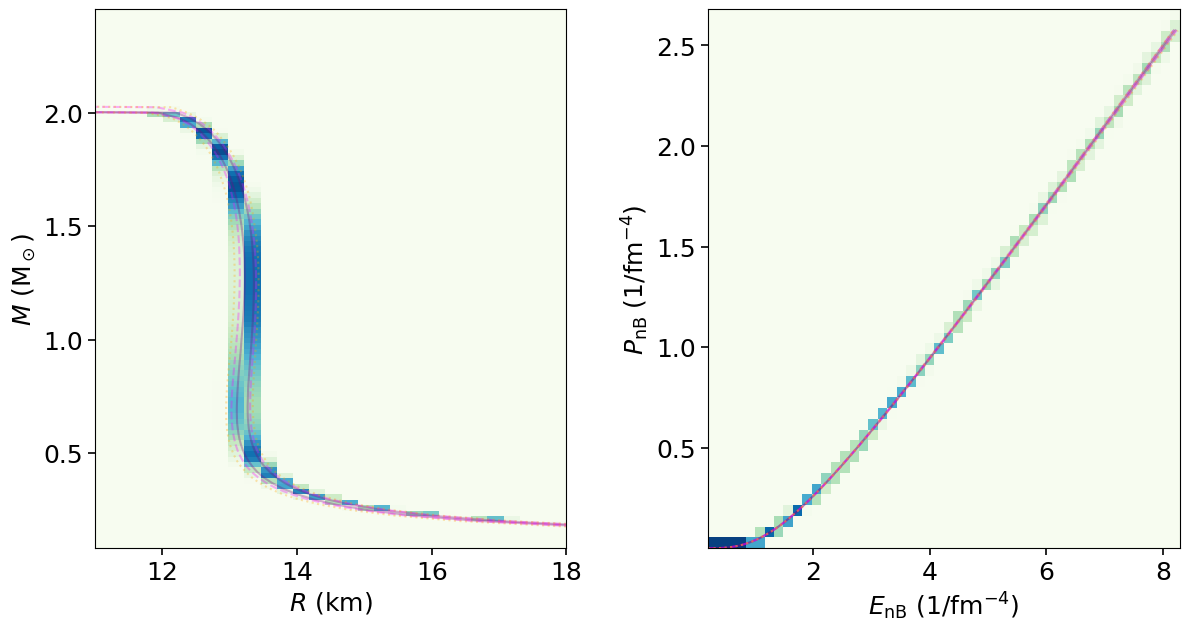

In [212]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7),gridspec_kw={'hspace': 0.3, 'wspace': 0.3})
axes=axes.flatten()
mass_grid=np.linspace(0.08, 2.456,100)

with h5py.File('../kde_faja', 'r') as file:
  # Iterate over the indices to fill the array
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  dct = file['table']['data'] 

  Pnb=[dct['Pnb'+f'_{i}'] for i in range(100)]  
  
  hist_t3d('R',dct,nlines,axes[0],r'$R~(\mathrm{km})$',r'$M~(\mathrm{M_\odot})$',mass_grid,
      [1800,100],['purple','magenta','orange'],'GnBu',False)
  axes[0].set_xlim(11,18)
  hist_t3d2('Enb',dct,nlines,axes[1],r'$P_{\mathrm{nB}}~(\mathrm{1/fm^{-4}})$','Pnb',
      [50,50],['purple','magenta','orange'],'GnBu',False)
  plt.savefig('eos_MR-PE.pdf')

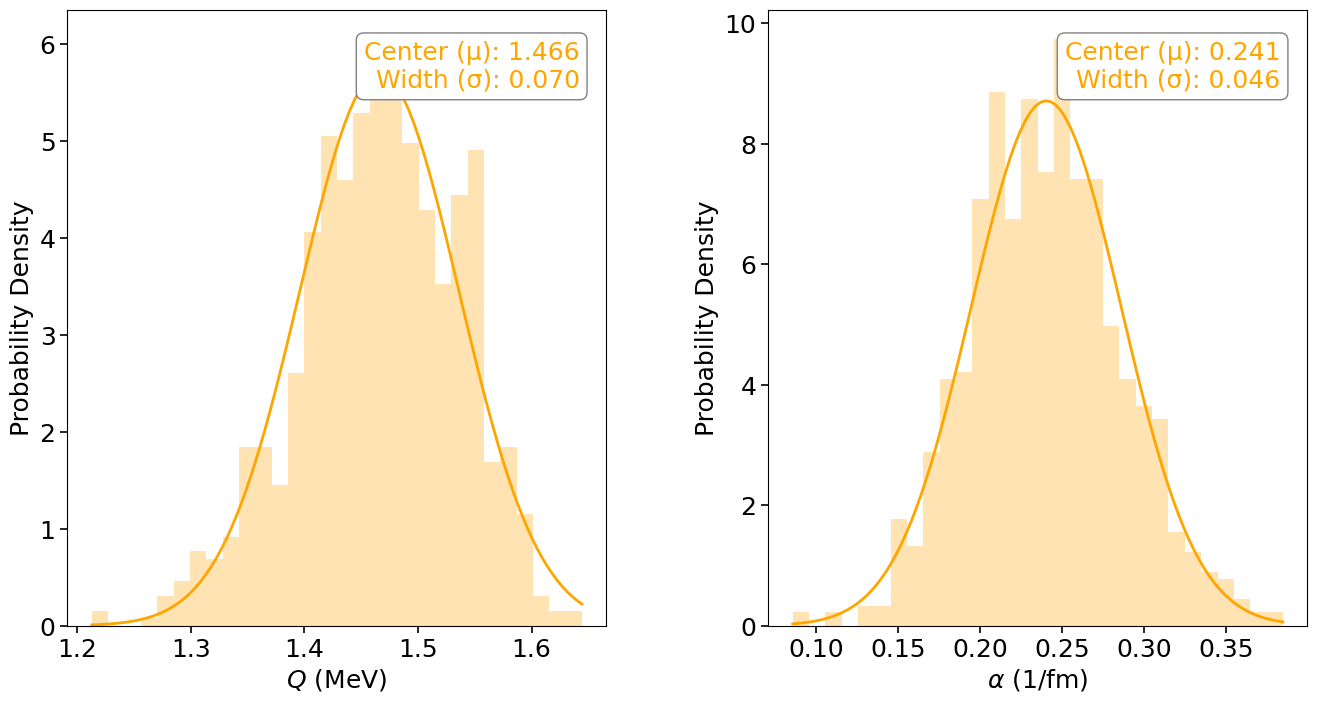

In [201]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8),gridspec_kw={'wspace':0.3,'hspace':0.5})
axes[0].tick_params(labelsize=18,width=1.2,length=5)
axes[1].tick_params(labelsize=18,width=1.2,length=5)
with h5py.File('../kde_faja', 'r') as file:
  # Iterate over the indices to fill the array
  Q = file['table']['data']['Q'] 
  alpha = file['table']['data']['alpha'] 

  hist_gauss1d(Q,axes[0],r'$Q~(\mathrm{MeV})$','orange',0.95,0.95)
  hist_gauss1d(alpha,axes[1],r'$\alpha~(\mathrm{1/fm})$','orange',0.95,0.95)
  #den_cont('Ligo',q,lambdat,axes)
  #plt.show(bbox_inches='tight')

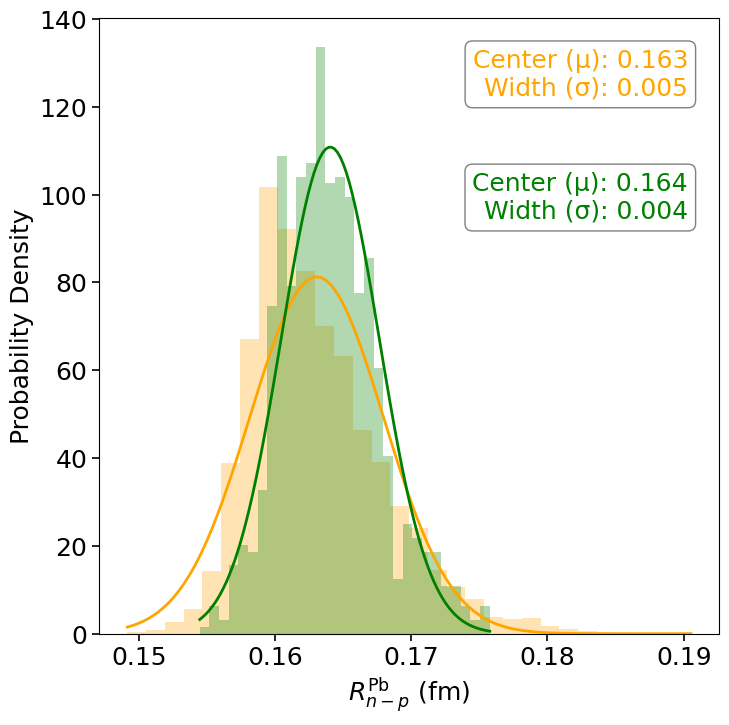

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 8),gridspec_kw={'wspace':0.3,'hspace':0.5})

with h5py.File('../noomma_tot_0_fix2_out', 'r') as file:
  rnrp_Pb208 = file['markov_chain_0']['data']['rnrp_Pb208']
  hist_gauss1d(rnrp_Pb208,axes,r'$rnrp_Pb208$','orange',0.95,0.95)
 
with h5py.File('../kde_faja', 'r') as file:
  rnrp_Pb208 = file['table']['data']['rnrp_Pb208'] 
  hist_gauss1d(rnrp_Pb208,axes,r'$R_{n-p}^{\mathrm{Pb}}~(\mathrm{fm})$','green',0.95,0.75)

plt.savefig('../../../sroy/nature/fig_compare/rnrp_Pb208.pdf', bbox_inches='tight')
plt.show()

PyModule : Reading test file: 


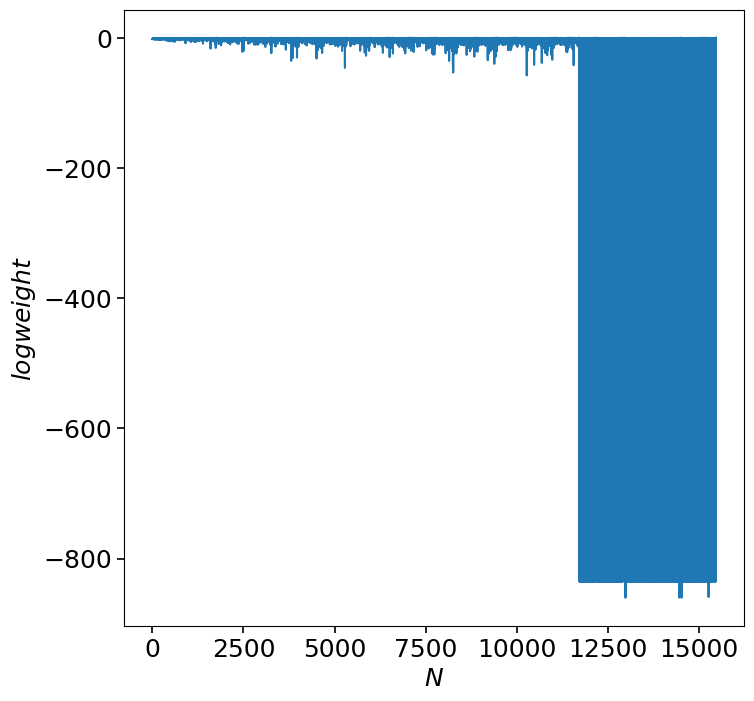

In [8]:
filename='../nomma2_0_out'
o2scl_settings=o2sclpy.lib_settings_class()
hf=o2sclpy.hdf_file()
print('PyModule : Reading test file: ')
hf.open(filename)
tab=o2sclpy.table()
name=b''
o2sclpy.hdf_input_table(hf,tab,name)
hf.close()

tab.delete_rows_func("log_wgt<(-800)")
log_wgt=tab['log_wgt']
#log_wgt.append(tab['log_wgt'][0:tab.get_nlines()])

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 8),gridspec_kw={'wspace':0.3,'hspace':0.5})
axes.set_xlabel(r'$N$',fontsize=18)
axes.set_ylabel(r'$log weight$',fontsize=18)
axes.tick_params(labelsize=18,width=1.2,length=5)
#axes[1].set_xlabel(r'$\alpha~(\mathrm{1/fm})$',fontsize=18)
#axes[1].set_ylabel(r'$N$',fontsize=18)
#axes[1].tick_params(labelsize=18,width=1.2,length=5)
#with h5py.File(filename, 'r') as file:
#  # Iterate over the indices to fill the array
#  nlines = file['markov_chain_0']['nlines'][0]  # Number of rows present in the file
#  dct = file['markov_chain_0']['data'] 
#  log_wgt=[]
#  #Q=[]
#  #alpha=[]
#  #for k in range(0,nlines):
#    #log_wgt.append(dct['log_wgt'][k])
#    #alpha.append(dct['alpha'][k])

axes.plot(log_wgt)
#axes[1].hist(alpha, bins=20, edgecolor='black', alpha=0.7)
#den_cont('Ligo',q,lambdat,axes)
plt.show()



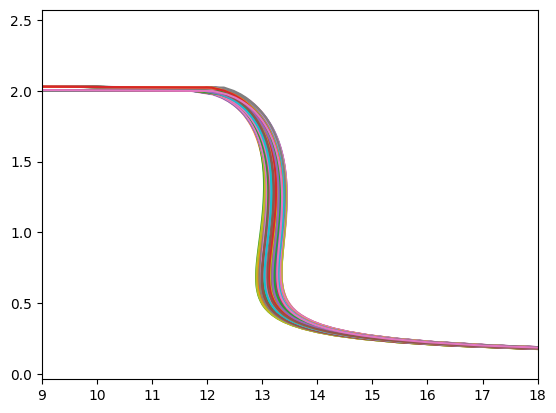

In [210]:
def plt_cc(name_list,i,dct,ax):
    for this_name in name_list[i]:  
            # The list that will contain the cooling curves     
            result=[]
            for k in range(0,nlines):
                # for each row get the maximum mass and the mass and eta
                # of the star
                Mns_max=dct['Mns_max'][k]
                mf_ins=dct['mf_'+this_name][k]
                M_ins=mf_ins*(Mns_max-1)+1
                try:
                    eta_ins=dct['eta_'+this_name][k]
                except:
                    eta_ins=-17.0
                # ---------------------------------------------------------------
                # Add the cooling curve to the list
                tmp=mass_eta_interp(L_tensor[k],M_ins,eta_ins,100,this_name)
                result.append(tmp)
                ax.plot(t_grid2,tmp)
                    
            # ---------------------------------------------------------------
            color=colormap(norm(M_ins))
            hist_cont(result,ax,color,'GnBu')

def hist_cont(result,ax,clrs,cmap):
    P=np.asarray(result)
    #plt_ci(nlines,0.68,P,ax,'-',clrs)
    #plt_ci(nlines,0.9,P,ax,'--',clrs)
    #plt_ci(nlines,0.99,P,ax,':',clrs)
    # Flatten the y-values and corresponding x-values for density plotting
    #x_flat = np.tile(t_grid2, nlines)
    #y_flat = P.flatten()

    # Create a 2D histogram for density
    #ax.hist2d(x_flat, y_flat, bins=[2000, 2000], cmap=cmap)
    ax.tick_params(labelsize=18,width=1.2,length=5)


fig, axes = plt.subplots(nrows=1, ncols=1)

lstT=[['J0007']]
with h5py.File('../kde_faja', 'r') as file:
    # Iterate over the indices to fill the array
    nlines = file['table']['nlines'][0]  # Number of rows present in the file
    dct = file['table']['data'] 
    R=[dct['R'+f'_{i}'] for i in range(100)]
    R=np.array(R).T
    #axes.set_yscale('log')
    #axes.set_xscale('log')
    axes.set_xlim(9,18)
    #plt_cc(lstT,0,dct,axes)
    for i in range(0,nlines):
      axes.plot(R[i],mass_grid)

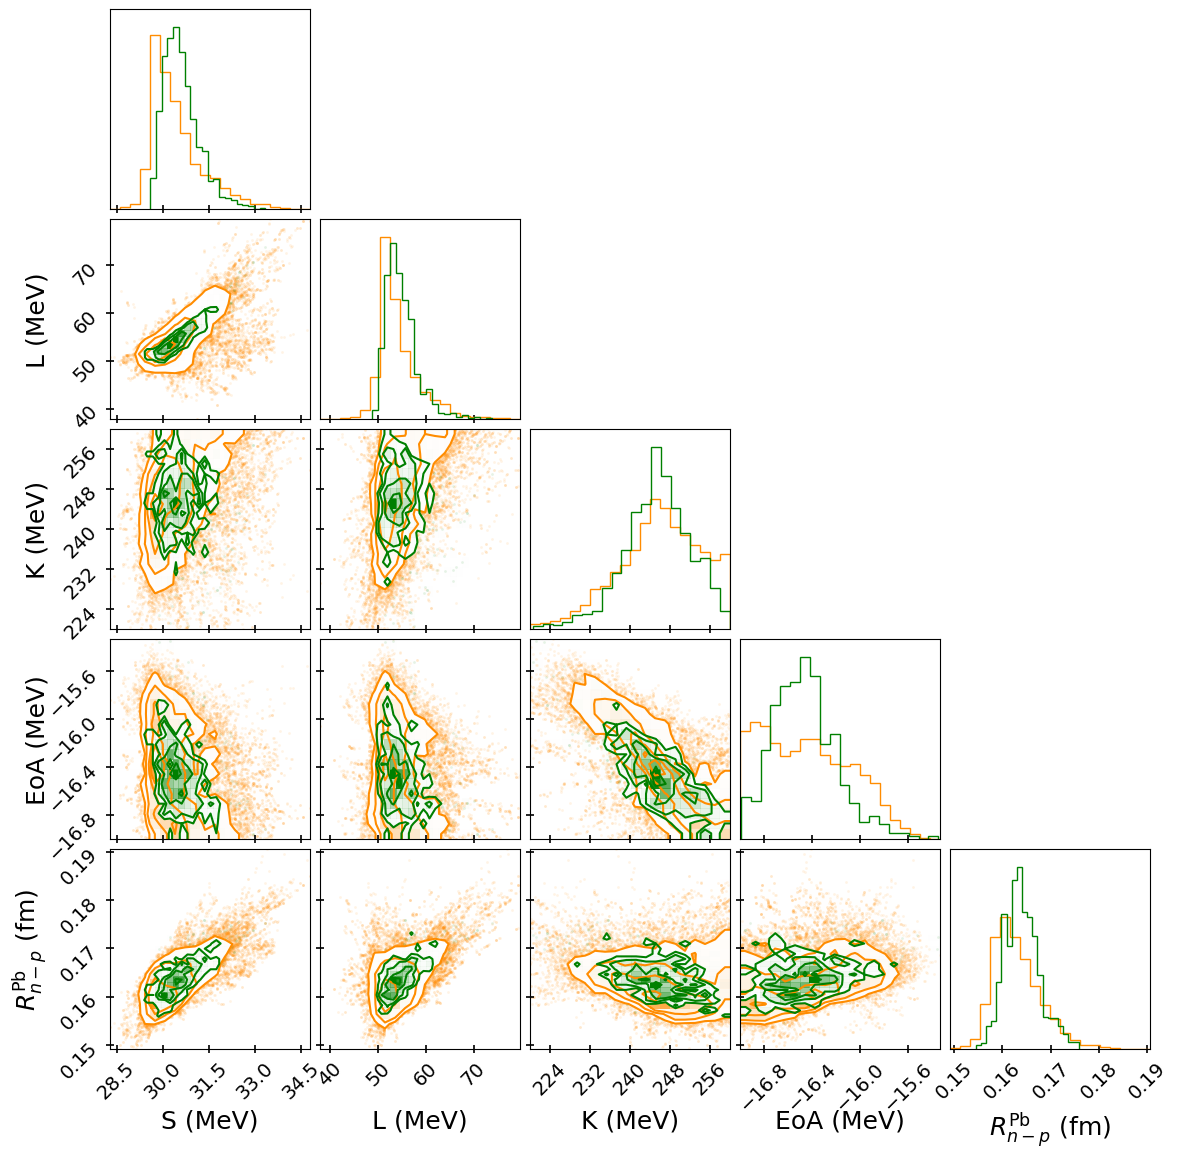

In [53]:
import corner
import numpy as np
import h5py

param_names = ['S', 'L', 'K', 'EoA', 'rnrp_Pb208']
label_names = ['S (MeV)', 'L (MeV)', 'K (MeV)', 'EoA (MeV)', r'$R_{n-p}^{\mathrm{Pb}}~(\mathrm{fm})$']

def load_mcmc_params(h5_path, param_names, chain_key='markov_chain_0/data'):
    with h5py.File(h5_path, 'r') as file:
        data_dict = {
            param: file[f"{chain_key}/{param}"][:] for param in param_names
        }
    data_array = np.vstack([data_dict[p] for p in param_names]).T
    return data_array, data_dict

# First dataset
data1, _ = load_mcmc_params('../noomma_tot_0_fix2_out', param_names)

fig = corner.corner(
    data1,
    labels=label_names,
    show_titles=False,
    hist_kwargs={"density": True},
    label_kwargs={"fontsize": 18},
    color="darkorange",
    plot_contours=True,
    fill_contours=False
)

# Second dataset — overlay on the same figure
data2, _ = load_mcmc_params('../kde_faja', param_names, 'table/data')

corner.corner(
    data2,
    labels=label_names,
    show_titles=False,
    hist_kwargs={"density": True},
    label_kwargs={"fontsize": 18},
    color="green",
    fig=fig,  # reuse the first figure here
    plot_contours=True,
    fill_contours=False
);

for ax in fig.get_axes():
    ax.tick_params(
        axis='both',       # x and y ticks
        labelsize=14,      # font size of tick labels
        width=1.2,         # thickness of the ticks
        length=6,          # length of the ticks
        direction='inout'  # optional: tick direction
    )


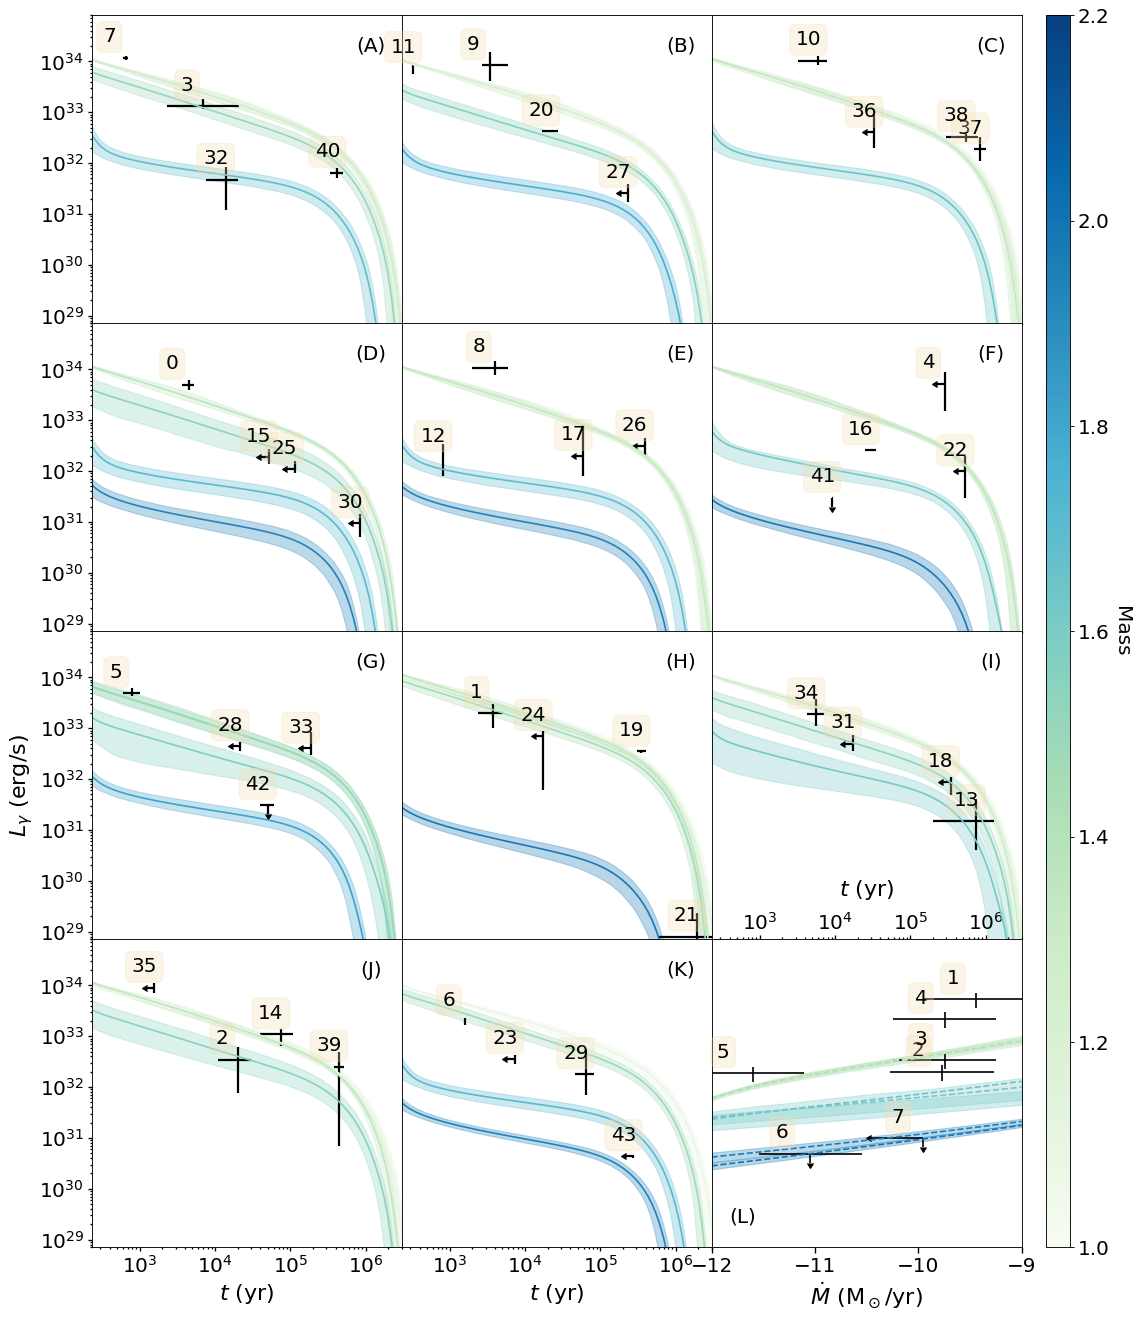

In [7]:
# Main file that will be used to plot the cooling curves
file_path='../kde_faja'
style=[':','--','-.']
letters = ['A','B','C','D','E','F','G','H','I','J','K','L']
# ---------------------------------------------------------------
# for 95% CI 
z_score=1.96
# ---------------------------------------------------------------
with h5py.File(file_path, 'r') as file:
  # Iterate over the indices to fill the array
  nlines = file['table']['nlines'][0]  # Number of rows present in the file
  dct = file['table']['data'] 
  Mns_max=dct['Mns_max']
  Mns_max_avg=np.mean(Mns_max)

  L_tensor = np.empty((nlines,3, 6, 100), dtype=np.float32)
  sL_tensor = np.empty((nlines,3, 6, 30), dtype=np.float32)

  for i, j, k in np.ndindex(3, 6, 100):
    L_tensor[:, i, j, k] = dct[f'cL_{i}_{j}_{k}'][:]

  for i, j, k in np.ndindex(3, 6, 30):
    sL_tensor[:, i, j, k] = dct[f'sL_{i}_{j}_{k}'][:]
  # ---------------------------------------------------------------
  # Create a colormap using Plasma colormap on the mass grid
  colormap = plt.cm.GnBu
  norm=plt.Normalize(1.0,2.2)
  sm=plt.cm.ScalarMappable(cmap=colormap,norm=norm)
  sm.set_array([])
  props = dict(boxstyle='round', edgecolor='wheat', facecolor='wheat', alpha=0.3)
  # ---------------------------------------------------------------

  # 12 subplots with shared y axis for luminosity
  fig, axes = plt.subplots(nrows=4, ncols=3, sharey=True, figsize=(15, 20),dpi=80,gridspec_kw={'hspace': 0, 'wspace': 0})
  axes=axes.flatten() # flatten the axis for easier indexing
  plt.ylim(7e28,8.0e34) # limit the luminosities for all subplots when sharey=True
  # ---------------------------------------------------------------
  lo=int(nlines/2.0-0.683/2.0*nlines)
  hi=int(nlines/2.0+0.683/2.0*nlines)

  # Plot the INS observed lum-age in 11 subplots
  for i in range(0,11):
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_xlim(2.3e2,3e6) # setting the xlims for each subplots as 12th subplot is different
    # Setting axis lables
    # ---------------------------------------------------------------
    if i==6:
      axes[i].set_ylabel(r'$ L_{\gamma}~(\mathrm{erg}/\mathrm{s}) $',fontsize=20)
    if i>8:
      axes[i].set_xlabel(r'$ t~(\mathrm{yr}) $',fontsize=20)
    # ---------------------------------------------------------------
    # Setting axis ticks for no overlap
    if i<8:
      labelbottom=False
    else:
      labelbottom=True

    if i%3==0:
      left=True
    else:
      left=False
    # ---------------------------------------------------------------
    axes[i].tick_params(labelsize=18,width=1.2,labelbottom=labelbottom,left=left,which='both')
    axes[i].text(0.9,0.9,'(%s)' % letters[i],fontsize=18,ha='center',va='center',transform=axes[i].transAxes)
    # ---------------------------------------------------------------
    for this_name in name_list[i]:
      plot_ins_data(dct,this_name,i)

  # Plot the SXRT observed lum-mdot
  axes[8].tick_params(labelsize=18,width=1.2,labelbottom=True,direction='in',pad=-25,which='both')
  axes[8].set_xlabel(r'$ t~(\mathrm{yr}) $',fontsize=20,labelpad=-55)
  axes[11].tick_params(labelsize=18,width=1.2,length=5,left=False,labelbottom=True,which='both')
  axes[11].text(0.1,0.1,'(%s)' % (letters[11]),fontsize=18,ha='center',va='center',transform=axes[11].transAxes)
  axes[11].set_xlim(-12,-9)
  axes[11].set_yscale('log')
  axes[11].set_xlabel(r'$\dot M~(\mathrm{M_\odot/yr}) $',fontsize=20)
  for i in range(0,len(sxrt_data["data/index"])):
    plot_sxrt_data(dct,sxrt_names[i],i)
  ind=0
  # -------------------------------------------------------------------
  # Plot the cooling curves for INSs
  for i in range(0,11): 
    for this_name in name_list[i]:  
      plot_cc(dct,this_name,i,True)
      ind+=1
      # ---------------------------------------------------------------
    
  # Plot the accretion curves for SXRTs
  for name in sxrt_names:
    plot_cc(dct,name,i,False)

# Add colorbar for mass
cax=fig.add_axes([0.92,0.11,0.02,0.77])
cbar=plt.colorbar(sm,cax=cax)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Mass',fontsize=18,rotation=270,labelpad=20)
#plt.savefig("../../nature/fig_compare/ins_aff.pdf", bbox_inches='tight')

plt.show()

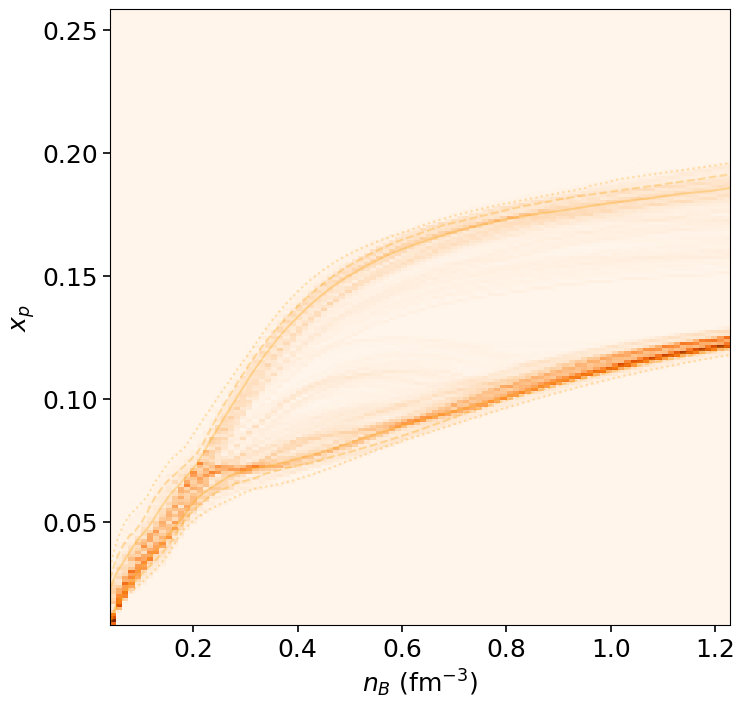

In [3]:
nB_grid=np.linspace(0.04, 1.228, 100)
fig, axes = plt.subplots(nrows=1,ncols=1,figsize=(8, 8))

with h5py.File('../temp1', 'r') as file:
# Iterate over the indices to fill the array
  nlines = file['markov_chain_0']['nlines'][0]  # Number of rows present in the file
  dct = file['markov_chain_0']['data'] 
  hist_t3d('xp',dct,nlines,axes,r'$n_B~(\mathrm{fm^{-3}})$',r'$x_p$',nB_grid,
    [100,200],['orange','orange','orange'],'Oranges',True)

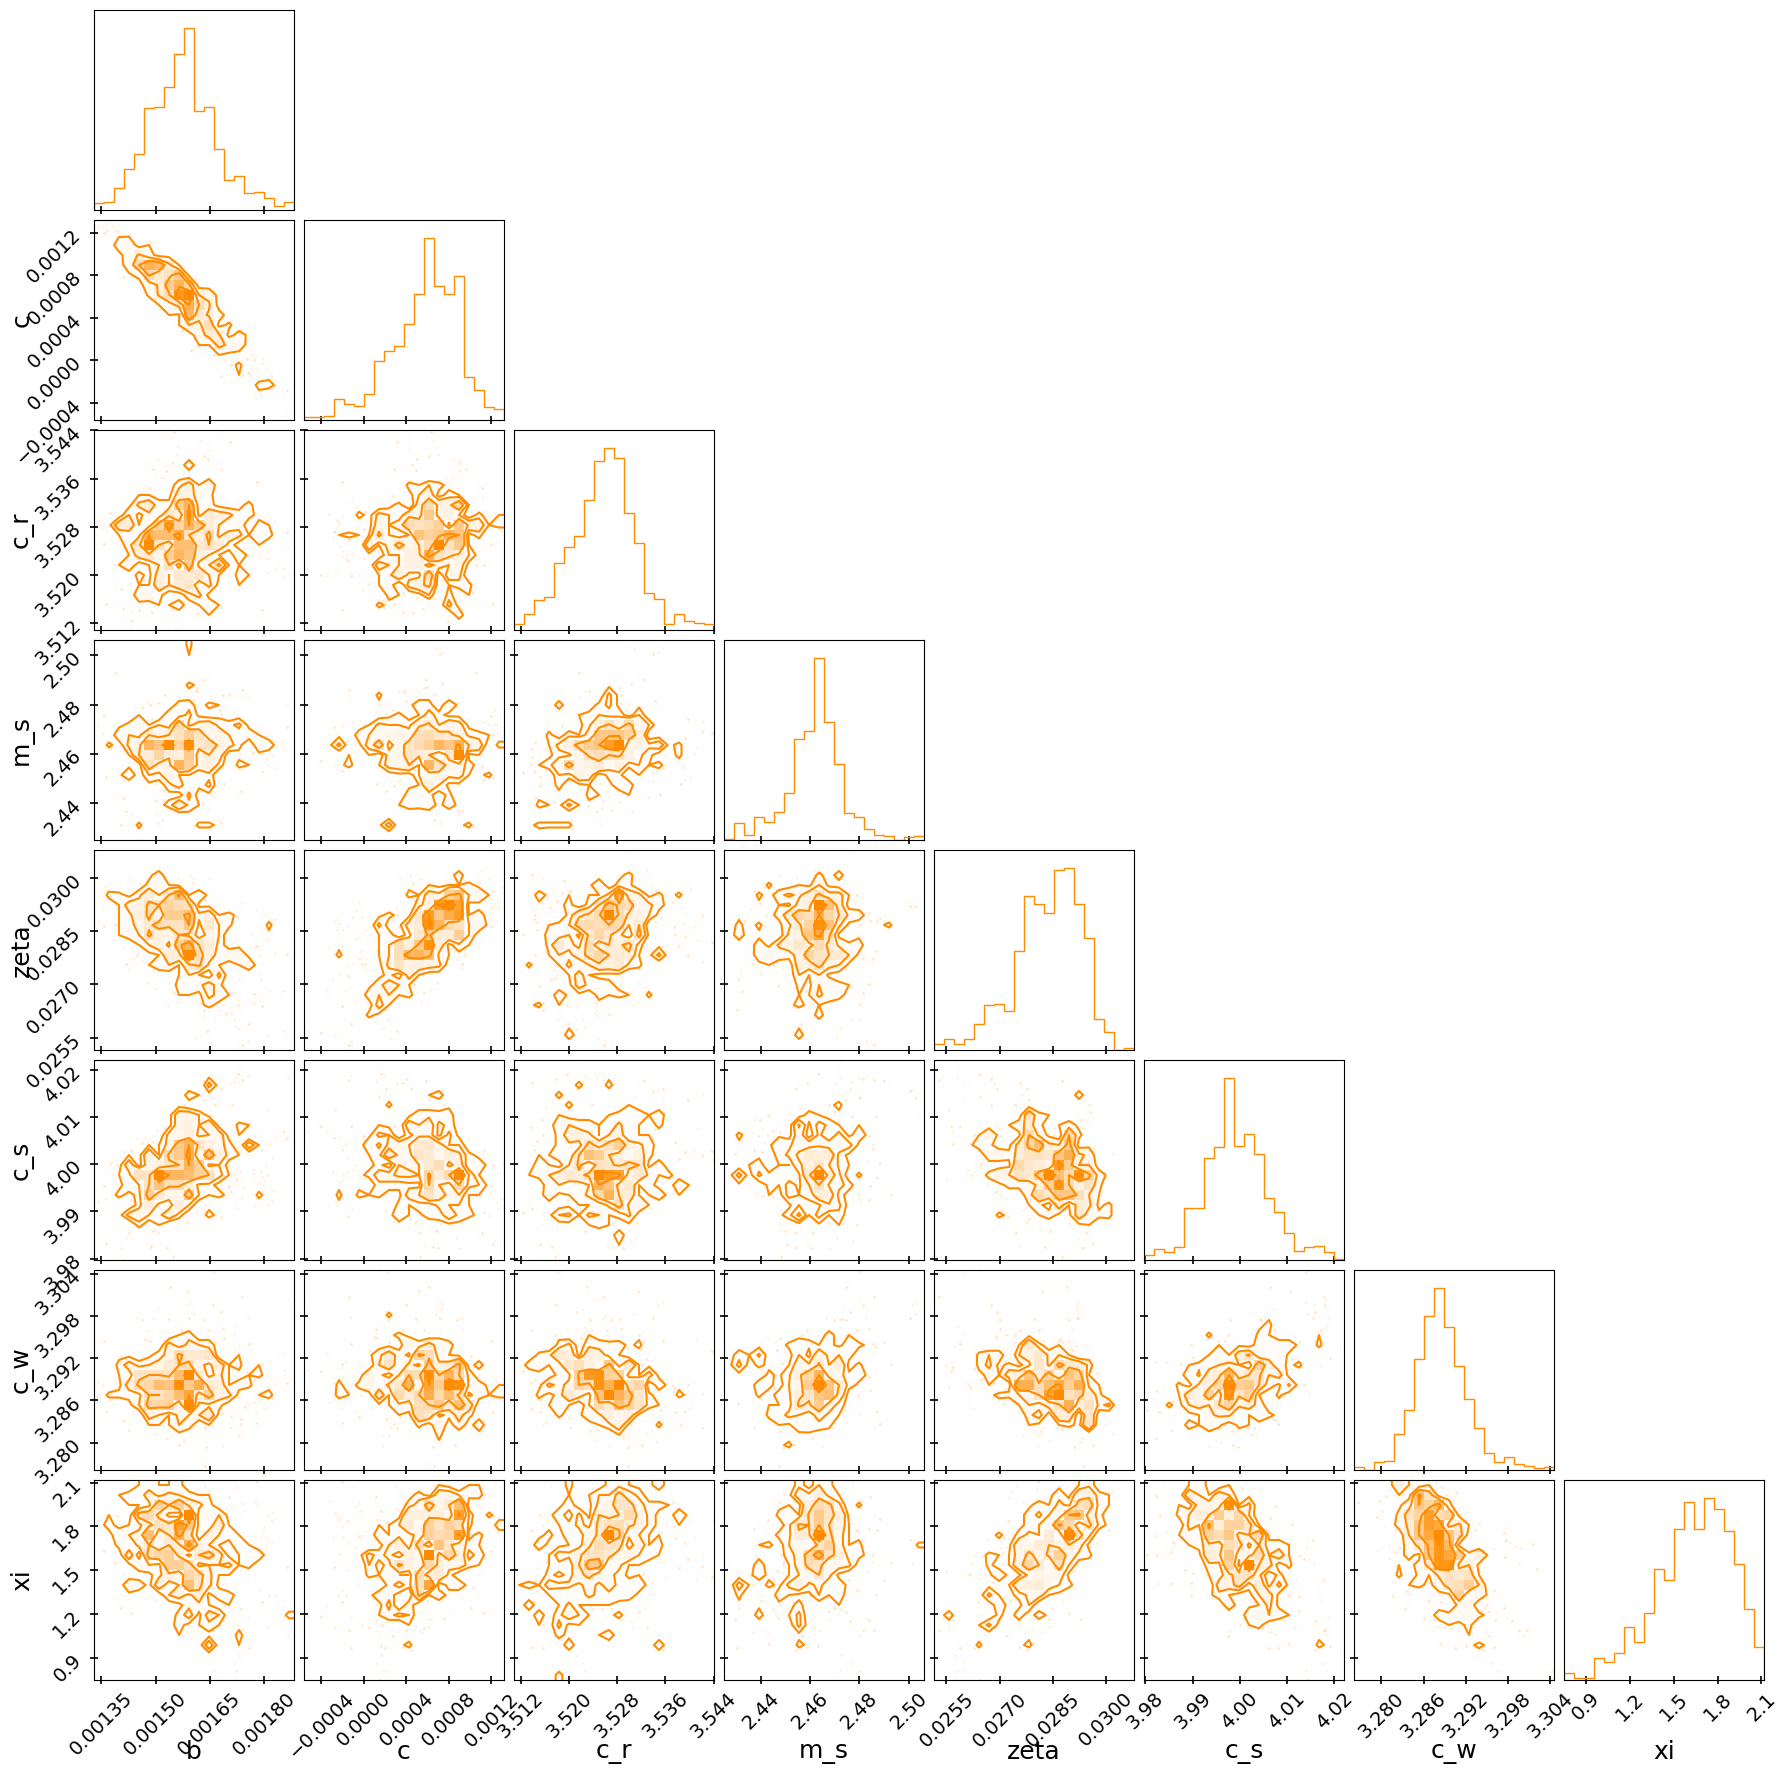

In [ ]:
import corner
import numpy as np
import h5py

param_names = ['b', 'c', 'c_r', 'm_s', 'zeta', 'c_s', 'c_w', 'xi''a1', 'a2' , 'a3', 'a4', 'a5' ,'a6', 'b1', 'b2', 'b3']
label_names = ['b', 'c', 'c_r', 'm_s', 'zeta', 'c_s', 'c_w', 'xi']

def load_mcmc_params(h5_path, param_names, chain_key='markov_chain_0/data'):
    with h5py.File(h5_path, 'r') as file:
        data_dict = {
            param: file[f"{chain_key}/{param}"][:] for param in param_names
        }
    data_array = np.vstack([data_dict[p] for p in param_names]).T
    return data_array, data_dict

# First dataset
data1, _ = load_mcmc_params('../kde_faja', param_names, 'table/data')

fig = corner.corner(
    data1,
    labels=label_names,
    show_titles=False,
    hist_kwargs={"density": True},
    label_kwargs={"fontsize": 18},
    color="darkorange",
    plot_contours=True,
    fill_contours=False
)

for ax in fig.get_axes():
    ax.tick_params(
        axis='both',       # x and y ticks
        labelsize=14,      # font size of tick labels
        width=1.2,         # thickness of the ticks
        length=6,          # length of the ticks
        direction='inout'  # optional: tick direction
    )


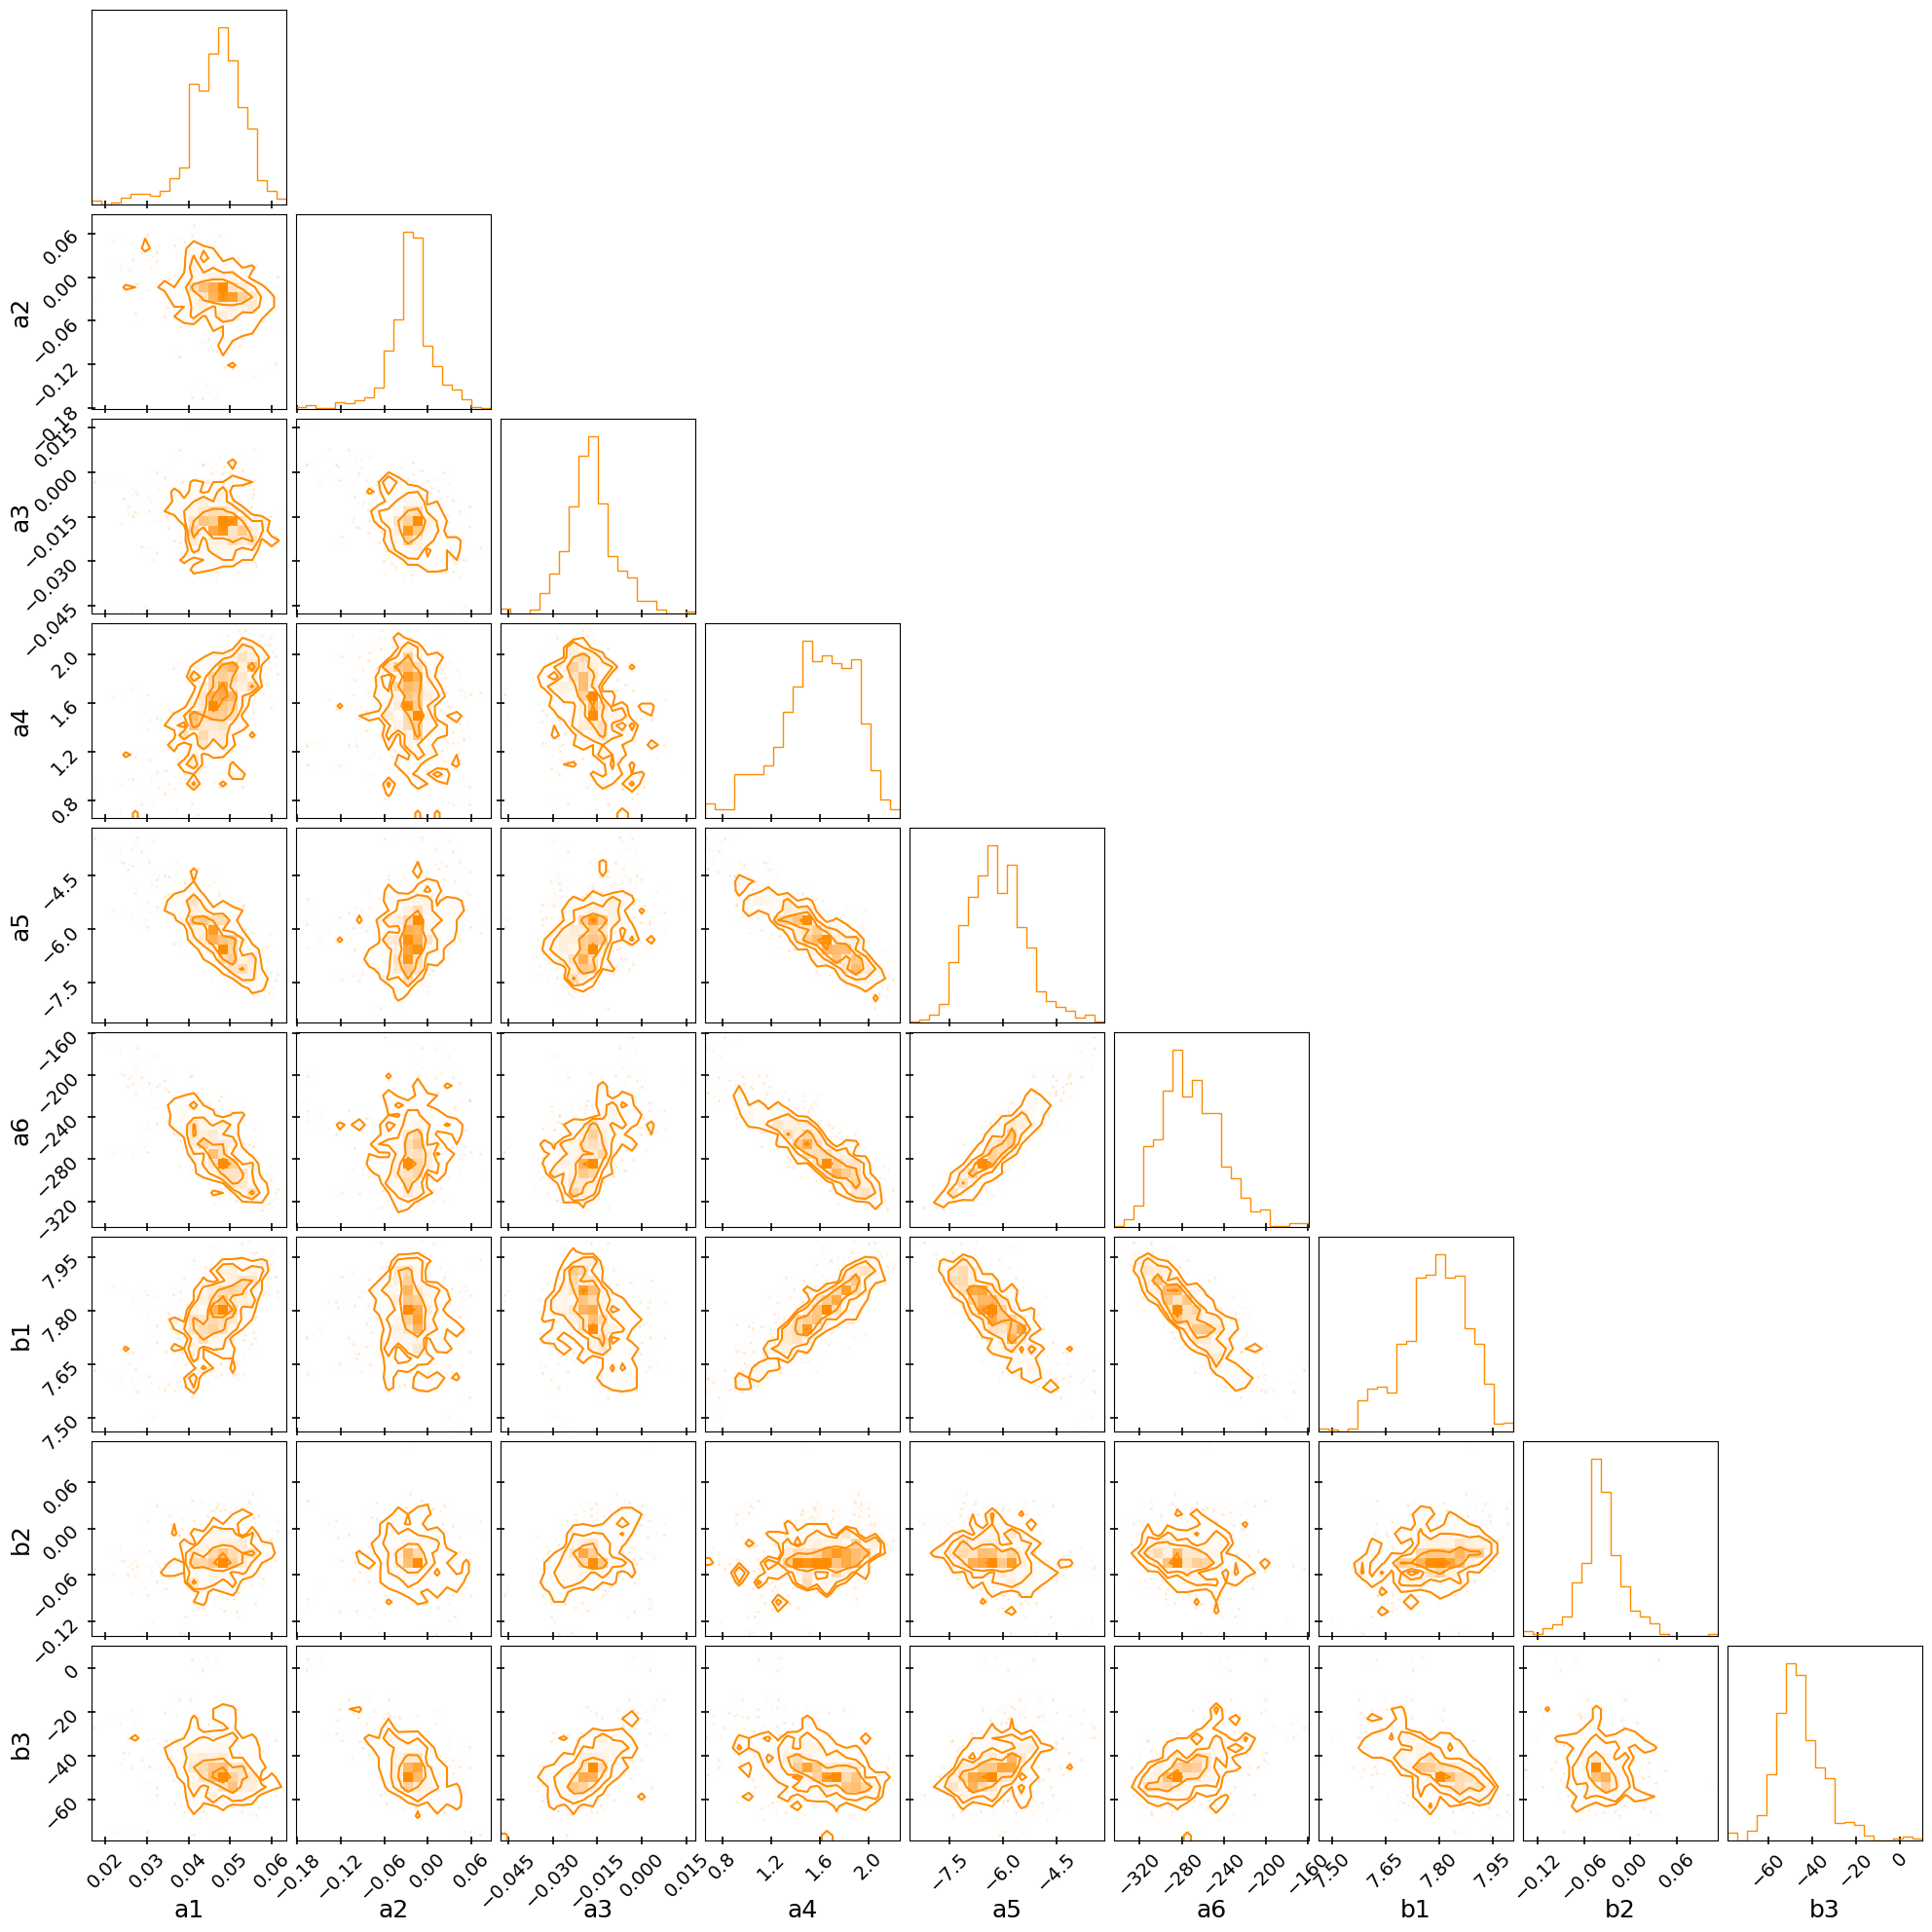

In [8]:
import corner
import numpy as np
import h5py

param_names = ['a1', 'a2' , 'a3', 'a4', 'a5' ,'a6', 'b1', 'b2', 'b3']
label_names = ['a1', 'a2' , 'a3', 'a4', 'a5' ,'a6', 'b1', 'b2', 'b3']

def load_mcmc_params(h5_path, param_names, chain_key='markov_chain_0/data'):
    with h5py.File(h5_path, 'r') as file:
        data_dict = {
            param: file[f"{chain_key}/{param}"][:] for param in param_names
        }
    data_array = np.vstack([data_dict[p] for p in param_names]).T
    return data_array, data_dict

# First dataset
data1, _ = load_mcmc_params('../kde_faja', param_names, 'table/data')

fig = corner.corner(
    data1,
    labels=label_names,
    show_titles=False,
    hist_kwargs={"density": True},
    label_kwargs={"fontsize": 18},
    color="darkorange",
    plot_contours=True,
    fill_contours=False
)

for ax in fig.get_axes():
    ax.tick_params(
        axis='both',       # x and y ticks
        labelsize=14,      # font size of tick labels
        width=1.2,         # thickness of the ticks
        length=6,          # length of the ticks
        direction='inout'  # optional: tick direction
    )
